# Final Project: Chronic Disease Risk Profiling Using Data Mining
#### **Group:** GR-1
#### **Members:** Sabina Bimbi, Ali Mansouri, Terence Mpofu, Lydia Tembreull
#### **Dataset:** CDC Chronic Disease Indicators (CDI)

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Environment Setup & Data Loading

In [2]:
# Google Colab drive mount
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running on Google Colab — skipping drive mount.")

Mounted at /content/drive


In [3]:
# Define possible paths
colab_path = '/content/drive/Othercomputers/My Laptop (1)/CS5831/CS5831-FINAL-PROJECT/U.S._Chronic_Disease_Indicators.csv' # <<< CHANGE THIS TO YOUR FILE PATH
local_path = 'U.S._Chronic_Disease_Indicators.csv'

# Check which one exists and load it
if os.path.exists(colab_path):
    csv_file_path = colab_path
    print("Running on Colab: Using Google Drive path.")
elif os.path.exists(local_path):
    csv_file_path = local_path
    print("Running Locally: Using local folder path.")
else:
    raise FileNotFoundError("Could not find the CSV file in Colab or Local directories.")

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
    display(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Running on Colab: Using Google Drive path.
CSV file loaded successfully!


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [4]:
df.shape

(309215, 34)

In [5]:
df.isnull().sum()

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Question,0
Response,309215
DataValueUnit,0
DataValueType,0


In [6]:
# Drop columns where all values are missing (empty)
df.dropna(axis = 1, how = 'all', inplace = True)

print("New shape after dropping empty columns:", df.shape)

New shape after dropping empty columns: (309215, 24)


# Data Transformation & Data Filtering

### Option1: Filter based on DataValueType = 'Crude Rate'

In [ ]:
# Filter the dataframe based on DataValueType (option1)
filtered_df = df[(df['DataValueType'] == 'Crude Rate')]

# Pivot the dataframe
# Index: columns to keep as rows
# Columns: convert Topic and Question to columns
# Values: DataValue
pivoted_df = filtered_df.pivot_table(
    index = ['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc'],
    columns = ['Topic', 'Question'],
    values = 'DataValue',
    aggfunc = 'first' # Using 'first' handles any potential duplicate combinations
).reset_index()

# Display the pivoted dataframe
display(pivoted_df.head())
print("Shape of pivoted dataframe:", pivoted_df.shape)

Topic    YearStart YearEnd LocationAbbr LocationDesc  \
Question                                               
0             2015    2019           AK       Alaska   
1             2015    2019           AL      Alabama   
2             2015    2019           AR     Arkansas   
3             2015    2019           AZ      Arizona   
4             2015    2019           CA   California   

Topic                                                               Alcohol  \
Question Chronic liver disease mortality among all people, underlying cause   
0                                                       NaN                   
1                                                       NaN                   
2                                                       NaN                   
3                                                       NaN                   
4                                                       NaN                   

Topic                                                 Asthma  \
Question Asthma mortality among all people, underlying cause   
0                                                       NaN    
1                                                       NaN    
2                                                       NaN    
3                                                       NaN    
4                                                       NaN    

Topic                                                         Cancer  \
Question Breast cancer mortality among all females, underlying cause   
0                                                      17.8            
1                                                      28.1            
2                                                      27.5            
3                                                      10.5            
4                                                      22.8            

Topic                                                                   \
Question Cervical cancer mortality among all females, underlying cause   
0                                                       1.8              
1                                                       3.6              
2                                                       3.8              
3                                                       2.3              
4                                                       3.5              

Topic                                                                                       \
Question Colon and rectum (colorectal) cancer mortality among all people, underlying cause   
0                                                      12.1                                  
1                                                      16.6                                  
2                                                       2.0                                  
3                                                      11.3                                  
4                                                      14.6                                  

Topic                                                                                       \
Question Invasive cancer (all sites combined) mortality among all people, underlying cause   
0                                                      77.6                                  
1                                                      51.3                                  
2                                                      27.2                                  
3                                                     170.8                                  
4                                                     157.2                                  

Topic     ...  \
Question  ...   
0         ...   
1         ...   
2         ...   
3         ...   
4         ...   

Topic                                                           Cardiovascular Disease  \
Question Cerebrovascular disease (stroke) mortality 

Shape of pivoted dataframe: (262, 23)


In [ ]:
pivoted_df.isnull().sum()

Topic                                  Question                                                                                                                        
YearStart                                                                                                                                                                    0
YearEnd                                                                                                                                                                      0
LocationAbbr                                                                                                                                                                 0
LocationDesc                                                                                                                                                                 0
Alcohol                                Chronic liver disease mortality among all people, underlying cause                           

In [ ]:
# Calculate the percentage of null values per column
null_percentage = (pivoted_df.isnull().sum() / len(pivoted_df)) * 100
notnull_count = len(pivoted_df) - pivoted_df.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 60.30534351145038, 54.961832061068705, 46.94656488549619, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 40.458015267175576, 0.0, 0.0, 0.0, 0.0]
[262, 262, 262, 262, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 139, 118, 104, 104, 104, 104, 104, 104, 104]


### Option2: Filter based on DataValueType = 'Crude Prevalence'

In [7]:
# Filter the dataframe based on DataValueType (option2)
filtered_df = df[(df['DataValueType'] == 'Crude Prevalence')]

# Pivot the dataframe
# Index: columns to keep as rows
# Columns: convert Topic and Question to columns
# Values: DataValue
pivoted_df2 = filtered_df.pivot_table(
    index = ['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc'],
    columns = ['Topic', 'Question'],
    values = 'DataValue',
    aggfunc = 'first' # Using 'first' handles any potential duplicate combinations
).reset_index()

# Display the pivoted dataframe
display(pivoted_df2.head())
print("Shape of pivoted dataframe:", pivoted_df2.shape)

Topic    YearStart YearEnd LocationAbbr LocationDesc  \
Question                                               
0             2018    2019           AK       Alaska   
1             2018    2019           AL      Alabama   
2             2018    2019           AR     Arkansas   
3             2018    2019           AZ      Arizona   
4             2018    2019           CA   California   

Topic                                   Alcohol  \
Question Alcohol use among high school students   
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

Topic                                            \
Question Binge drinking prevalence among adults   
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   

Topic                                                          \
Question Binge drinking prevalence among high school students   
0                                                       NaN     
1                                                       NaN     
2                                                       NaN     
3                                                       NaN     
4                                                       NaN     

Topic                                                           Arthritis  \
Question Activity limitation due to arthritis among adults with arthritis   
0                                                       NaN                 
1                                                       NaN                 
2                                                       NaN                 
3                                                       NaN                 
4                                                       NaN                 

Topic                            \
Question Arthritis among adults   
0                           NaN   
1                           NaN   
2                           NaN   
3                           NaN   
4                           NaN   

Topic                                                                                                           \
Question Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis   
0                                                       NaN                                                      
1                                                       NaN                                                      
2                                                       NaN                                                      
3                                                       NaN                                                      
4                                                       NaN                                                      

Topic     ...                       Social Determinants of Health  \
Question  ... No broadband internet subscription among households   
0         ...                                                NaN    
1         ...                                                NaN    
2         ...                                                NaN    
3         ...                                                NaN    
4         ...                                                NaN    

Topic                                                       \
Question Routine checkup within the past year among adults   
0                                                      NaN   
1                                                      NaN   
2                                                      NaN   
3                                                      N

Shape of pivoted dataframe: (476, 85)


#### Design Decision

**Option 1 (Crude Rate)** results in 262 rows and 23 disease indicators. **Option 2 (Crude Prevalence)** results in 476 rows and 85 disease indicators. We selected Crude Prevalence as our primary dataset, since it provides a significantly larger features space, which allows for higher model dimensionality. This has the potential to better capture complex relationships between various chronic conditions.

In [8]:
pivoted_df2.isnull().sum()

Topic         Question                                                             
YearStart                                                                                0
YearEnd                                                                                  0
LocationAbbr                                                                             0
LocationDesc                                                                             0
Alcohol       Alcohol use among high school students                                   382
                                                                                      ... 
Tobacco       Current cigarette smoking among adults                                   261
              Current electronic vapor product use among high school students          383
              Current smokeless tobacco use among high school students                 395
              Current tobacco use of any tobacco product among high school students    399
              Quit attempts in the past year among adult current smokers               325
Length: 85, dtype: int64

In [9]:
# Calculate the percentage of null values per column
null_percentage = (pivoted_df2.isnull().sum() / len(pivoted_df2)) * 100
notnull_count = len(pivoted_df2) - pivoted_df2.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[92.43697478991596, 92.01680672268907, 92.01680672268907, 92.01680672268907, 89.07563025210085, 88.8655462184874, 88.65546218487394, 88.65546218487394, 86.76470588235294, 86.76470588235294, 84.03361344537815, 83.82352941176471, 83.40336134453781, 83.40336134453781, 82.98319327731093, 82.56302521008404, 81.9327731092437, 81.5126050420168, 81.09243697478992, 80.46218487394958, 80.25210084033614, 80.0420168067227, 80.0420168067227, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 78.15126050420169, 77.73109243697479, 77.73109243697479, 77.73109243697479, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.52100840336135, 77.10084033613445, 77.10084033613445, 77.10084033613445, 77.10084033613445, 77.1008403361344

In [10]:
print(pivoted_df2.columns.tolist())

[('YearStart', ''), ('YearEnd', ''), ('LocationAbbr', ''), ('LocationDesc', ''), ('Alcohol', 'Alcohol use among high school students'), ('Alcohol', 'Binge drinking prevalence among adults'), ('Alcohol', 'Binge drinking prevalence among high school students'), ('Arthritis', 'Activity limitation due to arthritis among adults with arthritis'), ('Arthritis', 'Arthritis among adults'), ('Arthritis', 'Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis'), ('Arthritis', 'Physical inactivity among adults with arthritis'), ('Arthritis', 'Received health care provider counseling for physical activity among adults with arthritis'), ('Arthritis', 'Severe joint pain among adults with arthritis'), ('Arthritis', 'Work limitation due to arthritis among adults aged 18-64 years with arthritis'), ('Asthma', 'Current asthma among adults'), ('Cancer', 'Cervical cancer screening among women aged 21-65 years'), ('Cancer', 'Colorectal cancer screening among ad

### Rename Columns with Abbreviations

In [11]:
# --- 1) Define ID-column renaming ---
id_col_map = {
    ('YearStart', ''): 'yr_start',
    ('YearEnd', ''): 'yr_end',
    ('LocationAbbr', ''): 'state_abbr',
    ('LocationDesc', ''): 'state_name'
}

# --- 2) Define topic abbreviations ---
topic_abbr = {
    'Alcohol': 'alc',
    'Arthritis': 'arth',
    'Asthma': 'asth',
    'Cancer': 'can',
    'Cardiovascular Disease': 'cvd',
    'Chronic Obstructive Pulmonary Disease': 'copd',
    'Cognitive Health and Caregiving': 'cog',
    'Diabetes': 'dm',
    'Disability': 'dis',
    'Health Status': 'hs',
    'Immunization': 'imm',
    'Maternal Health': 'mat',
    'Mental Health': 'mh',
    'Nutrition, Physical Activity, and Weight Status': 'npaw',
    'Oral Health': 'oral',
    'Sleep': 'sleep',
    'Social Determinants of Health': 'sdoh',
    'Tobacco': 'tob'
}

# --- 3) Define question abbreviations ---
question_abbr = {
    ('Alcohol', 'Alcohol use among high school students'): 'alcohol_hs',
    ('Alcohol', 'Binge drinking prevalence among adults'): 'binge_adult',
    ('Alcohol', 'Binge drinking prevalence among high school students'): 'binge_hs',

    ('Arthritis', 'Activity limitation due to arthritis among adults with arthritis'): 'activity_limit_arth',
    ('Arthritis', 'Arthritis among adults'): 'arth_adult',
    ('Arthritis', 'Have taken an educational class to learn how to manage arthritis symptoms among adults with arthritis'): 'self_mgmt_class_arth',
    ('Arthritis', 'Physical inactivity among adults with arthritis'): 'inactive_arth',
    ('Arthritis', 'Received health care provider counseling for physical activity among adults with arthritis'): 'pa_counsel_arth',
    ('Arthritis', 'Severe joint pain among adults with arthritis'): 'severe_joint_pain_arth',
    ('Arthritis', 'Work limitation due to arthritis among adults aged 18-64 years with arthritis'): 'work_limit_arth_18_64',

    ('Asthma', 'Current asthma among adults'): 'asthma_adult',

    ('Cancer', 'Cervical cancer screening among women aged 21-65 years'): 'screen_cervical_w21_65',
    ('Cancer', 'Colorectal cancer screening among adults aged 45-75 years'): 'screen_colorectal_45_75',
    ('Cancer', 'Mammography use among women aged 50-74 years'): 'mammo_w50_74',

    ('Cardiovascular Disease', 'High blood pressure among adults'): 'hbp_adult',
    ('Cardiovascular Disease', 'High cholesterol among adults who have been screened'): 'high_chol_screened_adult',
    ('Cardiovascular Disease', 'Taking medicine for high cholesterol among adults'): 'med_high_chol_adult',
    ('Cardiovascular Disease', 'Taking medicine to control high blood pressure among adults with high blood pressure'): 'med_hbp_adult',

    ('Chronic Obstructive Pulmonary Disease', 'Chronic obstructive pulmonary disease among adults'): 'copd_adult',
    ('Chronic Obstructive Pulmonary Disease', 'Current smoking among adults with chronic obstructive pulmonary disease'): 'smoking_copd_adult',

    ('Cognitive Health and Caregiving', 'Discussed symptoms of subjective cognitive decline with a health care professional among adults aged 45 years and older with subjective cognitive decline'): 'scd_discussed_hcp_45plus',
    ('Cognitive Health and Caregiving', 'Provided care for a friend or family member in the past month among adults'): 'caregiver_friend_family_adult',
    ('Cognitive Health and Caregiving', 'Provided care for someone with dementia or other cognitive impairment in the past month among adults'): 'caregiver_dementia_adult',
    ('Cognitive Health and Caregiving', 'Subjective cognitive decline among adults aged 45 years and older'): 'scd_45plus',

    ('Diabetes', 'Diabetes among adults'): 'diabetes_adult',
    ('Diabetes', 'Gestational diabetes among women with a recent live birth'): 'gest_diabetes_recent_birth',

    ('Disability', 'Adults with any disability'): 'any_disability_adult',

    ('Health Status', '2 or more chronic conditions among adults'): 'chronic2plus_adult',
    ('Health Status', 'Fair or poor self-rated health status among adults'): 'fair_poor_health_adult',
    ('Health Status', 'Frequent physical distress among adults'): 'phys_distress_freq_adult',

    ('Immunization', 'Influenza vaccination among adults'): 'flu_vax_adult',
    ('Immunization', 'Influenza vaccination among adults 18â€“64 who are at increased risk'): 'flu_vax_risk_18_64',
    ('Immunization', 'Pneumococcal vaccination among adults aged 18â€“64 years who are at increased risk'): 'pneumo_vax_risk_18_64',
    ('Immunization', 'Pneumococcal vaccination among adults aged 65 years and older'): 'pneumo_vax_65plus',

    ('Maternal Health', 'Postpartum checkup among women with a recent live birth'): 'postpartum_check_recent_birth',

    ('Mental Health', 'Current poor mental health among high school students'): 'poor_mh_hs',
    ('Mental Health', 'Depression among adults'): 'depression_adult',
    ('Mental Health', 'Frequent mental distress among adults'): 'mental_distress_freq_adult',
    ('Mental Health', 'Postpartum depressive symptoms among women with a recent live birth'): 'postpartum_depr_recent_birth',

    ('Nutrition, Physical Activity, and Weight Status', 'Children and adolescents aged 6-13 years meeting aerobic physical activity guideline'): 'pa_guideline_6_13',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed fruit less than one time daily among adults'): 'fruit_lt1_daily_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed fruit less than one time daily among high school students'): 'fruit_lt1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed regular soda at least one time daily among high school students'): 'soda_ge1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed vegetables less than one time daily among adults'): 'veg_lt1_daily_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Consumed vegetables less than one time daily among high school students'): 'veg_lt1_daily_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Infants who were breastfed at 12 months'): 'breastfed_12m',
    ('Nutrition, Physical Activity, and Weight Status', 'Infants who were exclusively breastfed through 6 months'): 'exclusive_breastfed_6m',
    ('Nutrition, Physical Activity, and Weight Status', 'Met aerobic physical activity guideline among high school students'): 'pa_guideline_hs',
    ('Nutrition, Physical Activity, and Weight Status', 'Met aerobic physical activity guideline for substantial health benefits, adults'): 'pa_guideline_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'No leisure-time physical activity among adults'): 'no_leisure_pa_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among WIC children aged 2 to 4 years'): 'obesity_wic_2_4',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among adults'): 'obesity_adult',
    ('Nutrition, Physical Activity, and Weight Status', 'Obesity among high school students'): 'obesity_hs',

    ('Oral Health', 'All teeth lost among adults aged 65 years and older'): 'all_teeth_lost_65plus',
    ('Oral Health', 'No teeth lost among adults aged 18-64 years'): 'no_teeth_lost_18_64',
    ('Oral Health', 'Preventive dental care in the 12 months before pregnancy among women with a recent live birth'): 'prev_dental_pre_preg_recent_birth',
    ('Oral Health', 'Receipt of evidence-based preventive dental services in the past 12 months among children and adolescents aged 1-17 years'): 'prev_dental_child_1_17',
    ('Oral Health', 'Six or more teeth lost among adults aged 65 years and older'): 'teeth_lost_6plus_65plus',
    ('Oral Health', 'Visited dentist or dental clinic in the past year among adults'): 'dentist_visit_past_year_adult',
    ('Oral Health', 'Visited dentist or other oral health care provider in the past 12 months among children and adolescents aged 1-17 years'): 'dentist_visit_child_1_17',

    ('Sleep', 'Short sleep duration among adults'): 'short_sleep_adult',
    ('Sleep', 'Short sleep duration among children aged 4 months to 14 years'): 'short_sleep_child_4m_14y',
    ('Sleep', 'Short sleep duration among high school students'): 'short_sleep_hs',

    ('Social Determinants of Health', 'Food insecure in the past 12 months among households'): 'food_insecure_household',
    ('Social Determinants of Health', 'Health insurance coverage after pregnancy among women with a recent live birth'): 'ins_after_preg_recent_birth',
    ('Social Determinants of Health', 'Health insurance coverage in the month before pregnancy among women with a recent live birth'): 'ins_before_preg_recent_birth',
    ('Social Determinants of Health', 'High school completion among adults aged 18-24'): 'hs_completion_18_24',
    ('Social Determinants of Health', 'Lack of health insurance among adults aged 18-64 years'): 'no_ins_18_64',
    ('Social Determinants of Health', 'Lack of reliable transportation in the past 12 months among adults'): 'no_transport_adult',
    ('Social Determinants of Health', 'Lack of social and emotional support needed among adults'): 'no_social_emotional_support_adult',
    ('Social Determinants of Health', 'Living below 150% of the poverty threshold among all people'): 'poverty_lt150_all',
    ('Social Determinants of Health', 'No broadband internet subscription among households'): 'no_broadband_household',
    ('Social Determinants of Health', 'Routine checkup within the past year among adults'): 'routine_checkup_adult',
    ('Social Determinants of Health', 'Unable to pay mortgage, rent, or utility bills in the past 12 months among adults'): 'housing_utility_payment_issue_adult',
    ('Social Determinants of Health', 'Unemployment rate among people 16 years and older in the labor force'): 'unemployment_16plus_lf',

    ('Tobacco', 'Cigarette smoking during pregnancy among women with a recent live birth'): 'smoking_preg_recent_birth',
    ('Tobacco', 'Current cigarette smoking among adults'): 'cig_smoking_adult',
    ('Tobacco', 'Current electronic vapor product use among high school students'): 'vape_hs',
    ('Tobacco', 'Current smokeless tobacco use among high school students'): 'smokeless_hs',
    ('Tobacco', 'Current tobacco use of any tobacco product among high school students'): 'any_tobacco_hs',
    ('Tobacco', 'Quit attempts in the past year among adult current smokers'): 'quit_attempt_adult_smokers'
}

# --- 4) Flatten columns and create mapping table ---
new_columns = []
mapping_rows = []

for col in pivoted_df2.columns:
    # If not a tuple, keep as-is
    if not isinstance(col, tuple):
        new_name = col
        orig_topic = ''
        orig_question = ''
    else:
        if col in id_col_map:
            new_name = id_col_map[col]
            orig_topic, orig_question = col
        else:
            topic, question = col
            t_abbr = topic_abbr.get(topic, topic.lower().replace(' ', '_'))
            q_abbr = question_abbr.get((topic, question), question.lower().replace(' ', '_'))
            new_name = f"{t_abbr}__{q_abbr}"
            orig_topic = topic
            orig_question = question

    new_columns.append(new_name)
    mapping_rows.append({
        'new_column': new_name,
        'original_topic': orig_topic,
        'original_question': orig_question
    })

# Apply flattened names
pivoted_df2.columns = new_columns

# Create guideline / dictionary table
col_guideline_df = pd.DataFrame(mapping_rows)

# Optional: sort the guideline table for readability
col_guideline_df = col_guideline_df.sort_values(
    by = ['original_topic', 'original_question', 'new_column'],
    na_position = 'first'
).reset_index(drop = True)

# Show outputs
display(pivoted_df2.head())
display(col_guideline_df)

print("New shape:", pivoted_df2.shape)
print("Example columns:")
print(pivoted_df2.columns.tolist()[:20])

,yr_start,yr_end,state_abbr,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,2018,2019,AK,Alaska,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,2019,AL,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018,2019,AR,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018,2019,AZ,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,2019,CA,California,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,new_column,original_topic,original_question
0,alc__alcohol_hs,Alcohol,Alcohol use among high school students
1,alc__binge_adult,Alcohol,Binge drinking prevalence among adults
2,alc__binge_hs,Alcohol,Binge drinking prevalence among high school st...
3,arth__activity_limit_arth,Arthritis,Activity limitation due to arthritis among adu...
4,arth__arth_adult,Arthritis,Arthritis among adults
...,...,...,...
80,tob__smokeless_hs,Tobacco,Current smokeless tobacco use among high schoo...
81,tob__any_tobacco_hs,Tobacco,Current tobacco use of any tobacco product amo...
82,tob__quit_attempt_adult_smokers,Tobacco,Quit attempts in the past year among adult cur...
83,yr_end,YearEnd,


New shape: (476, 85)
Example columns:
['yr_start', 'yr_end', 'state_abbr', 'state_name', 'alc__alcohol_hs', 'alc__binge_adult', 'alc__binge_hs', 'arth__activity_limit_arth', 'arth__arth_adult', 'arth__self_mgmt_class_arth', 'arth__inactive_arth', 'arth__pa_counsel_arth', 'arth__severe_joint_pain_arth', 'arth__work_limit_arth_18_64', 'asth__asthma_adult', 'can__screen_cervical_w21_65', 'can__screen_colorectal_45_75', 'can__mammo_w50_74', 'cvd__hbp_adult', 'cvd__high_chol_screened_adult']


In [ ]:
col_guideline_df.to_csv("column_abbreviation_guide.csv", index = False)

In [ ]:
pivoted_df2.to_csv("pivoted_df2.csv", index = False)

### Handle Missing Values & Finalize Cleaning

Imputation of Missing Values

To address missing values in the dataset, we applied a group-wise K-nearest neighbors (KNN) imputation strategy. Since indicator availability varies across time windows, imputation was performed separately for each
(
yr_start
,
yr_end
)
(yr_start,yr_end) group to preserve temporal consistency and avoid mixing information across different years.

Within each time window, we first calculated the proportion of missing values for each indicator. Only indicators with less than 30% missing values were selected for imputation, as higher levels of missingness can lead to unreliable estimates. Indicators exceeding this threshold were excluded from the imputation process for that group.

For the selected indicators, we used a KNN imputer (with
k=5), which replaces missing values based on the average of the nearest neighboring states with similar feature profiles. This approach preserves multivariate relationships between indicators and is more robust than simple mean imputation, especially when data are not missing completely at random.

The imputed values were then written back to the dataset, ensuring that each time window was processed independently. This procedure reduces missingness while maintaining the underlying structure of the data.

In [12]:
from sklearn.impute import KNNImputer
import numpy as np

# Create a copy to avoid SettingWithCopyWarning
clean_df = pivoted_df2.copy()

# Get indicator columns
indicator_cols = [col for col in clean_df.columns if '__' in col]

# Initialize KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Group by yr_start and yr_end, then apply KNN imputation
for (yr_start, yr_end), group_df in clean_df.groupby(['yr_start', 'yr_end']):

    # Calculate missing percentage for each indicator WITHIN the group
    missing_pct = group_df[indicator_cols].isnull().mean()

    # Identify columns to impute with KNN (< 30% missing in this group)
    knn_cols = missing_pct[missing_pct < 0.3].index.tolist()

    if knn_cols:
        # Fit and transform the group for valid columns
        imputed_values = knn_imputer.fit_transform(group_df[knn_cols])

        # Assign the imputed values back to the main dataframe
        clean_df.loc[group_df.index, knn_cols] = imputed_values


print("Imputation complete. Total missing values remaining:", clean_df[indicator_cols].isnull().sum().sum())

Imputation complete. Total missing values remaining: 27958


In [ ]:
clean_df.to_csv("clean_df.csv", index = False)

In [ ]:
'''
# Check how much data is missing per indicator
missing_info = pivoted_df2.isnull().sum().sort_values(ascending = False)
print("Missing values per indicator:\n", missing_info.head(10))

# Fill missing values with the median for that indicator
clean_df = pivoted_df2.fillna(pivoted_df2.median(numeric_only = True))

Missing values per indicator:
 mh__poor_mh_hs                               440
sdoh__no_social_emotional_support_adult      438
sdoh__housing_utility_payment_issue_adult    438
sdoh__no_transport_adult                     438
sdoh__food_insecure_household                424
npaw__pa_guideline_adult                     423
npaw__obesity_wic_2_4                        422
can__screen_cervical_w21_65                  422
cog__caregiver_dementia_adult                413
cog__caregiver_friend_family_adult           413
dtype: int64


In [ ]:
'''
# Z-Score Normalization

# Identify columns that are disease indicators
indicator_cols = [col for col in clean_df.columns if '__' in col]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clean_df[indicator_cols])

# Create DataFrame of scaled values
scaled_df = pd.DataFrame(scaled_data, columns = indicator_cols)

### Aggregate indicators across time windows

In [14]:
clean_df.shape

(476, 85)

In [15]:
clean_df_alltime = clean_df.groupby(['state_name'])[indicator_cols].mean().reset_index()

print("Aggregated DataFrame shape:", clean_df_alltime.shape)
display(clean_df_alltime.head())

Aggregated DataFrame shape: (55, 82)


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__housing_utility_payment_issue_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,16.60,71.175000,23.5,6.70,9.466667,16.750,21.20,3.95,25.70,57.450000
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,11.60,69.025000,19.2,6.30,16.700000,20.675,23.24,7.92,30.60,42.150000
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,10.55,71.075000,7.9,5.30,8.300000,15.050,20.75,2.65,23.55,55.850000
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,17.00,68.233333,NaN,4.85,9.766667,14.275,10.95,4.80,19.60,53.833333
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,8.60,68.425000,13.8,6.35,5.330000,11.075,20.21,1.16,21.54,62.100000


In [17]:
# Calculate the percentage of null values per column
null_percentage = (clean_df_alltime.isnull().sum() / len(clean_df_alltime)) * 100
notnull_count = len(clean_df_alltime) - clean_df_alltime.isnull().sum()

# Sort the percentages in descending order for better visibility
null_percentage = null_percentage.sort_values(ascending = False)
notnull_count = notnull_count.sort_values(ascending = False)
print("Percentage of null values per column:")
print(null_percentage.tolist())
print(notnull_count.tolist())

Percentage of null values per column:
[34.54545454545455, 30.909090909090907, 30.909090909090907, 30.909090909090907, 9.090909090909092, 9.090909090909092, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 5.454545454545454, 1.8181818181818181, 1.8181818181818181, 1.8181818181818181, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 54, 54, 54, 52, 52, 52, 52, 52, 52, 52, 50, 50, 38, 38, 

In [18]:
# Calculate missing percentages for clean_df_alltime
missing_pct_alltime = clean_df_alltime.isnull().mean() * 100

# Identify columns to drop (more than 30% missing)
cols_to_drop = missing_pct_alltime[missing_pct_alltime > 30].index.tolist()

# Drop identified columns
clean_df_alltime_processed = clean_df_alltime.drop(columns=cols_to_drop)

# Identify columns to impute (less than or equal to 30% missing and still have NaNs)
cols_to_impute = clean_df_alltime_processed.columns[clean_df_alltime_processed.isnull().any()].tolist()

# Impute missing values with the mean for the remaining indicator columns
for col in cols_to_impute:
    if '__' in col: # Only impute indicator columns, not 'state_name'
        clean_df_alltime_processed[col] = clean_df_alltime_processed[col].fillna(clean_df_alltime_processed[col].mean())

print(f"Dropped {len(cols_to_drop)} columns with >30% missing values.")
print(f"Imputed remaining missing values in {len(cols_to_impute)} columns with the mean.")
print("Total missing values remaining after processing:", clean_df_alltime_processed.isnull().sum().sum())

display(clean_df_alltime_processed.head())

Dropped 4 columns with >30% missing values.
Imputed remaining missing values in 12 columns with the mean.
Total missing values remaining after processing: 0


,state_name,alc__alcohol_hs,alc__binge_adult,alc__binge_hs,arth__activity_limit_arth,arth__arth_adult,arth__self_mgmt_class_arth,arth__inactive_arth,arth__pa_counsel_arth,arth__severe_joint_pain_arth,...,sdoh__poverty_lt150_all,sdoh__no_broadband_household,sdoh__routine_checkup_adult,sdoh__unemployment_16plus_lf,tob__smoking_preg_recent_birth,tob__cig_smoking_adult,tob__vape_hs,tob__smokeless_hs,tob__any_tobacco_hs,tob__quit_attempt_adult_smokers
0,Alabama,14.05,11.375,8.97,19.10,30.900000,16.65,35.55,54.05,43.65,...,30.55,16.60,71.175000,6.70,9.466667,16.750,21.20,3.95,25.70,57.450000
1,Alaska,18.75,19.350,9.67,12.00,25.200000,17.40,21.55,67.95,23.45,...,26.15,11.60,69.025000,6.30,16.700000,20.675,23.24,7.92,30.60,42.150000
2,Arizona,27.90,16.025,12.90,5.40,25.566667,24.05,31.30,61.75,28.30,...,27.65,10.55,71.075000,5.30,8.300000,15.050,20.75,2.65,23.55,55.850000
3,Arkansas,26.00,8.400,9.75,11.90,26.900000,14.15,33.65,71.70,33.55,...,28.50,17.00,68.233333,4.85,9.766667,14.275,10.95,4.80,19.60,53.833333
4,California,26.39,13.975,7.89,7.35,30.266667,17.75,34.65,70.30,35.40,...,27.60,8.60,68.425000,6.35,5.330000,11.075,20.21,1.16,21.54,62.100000


In [19]:
clean_df_alltime_processed.to_csv("clean_df_alltime_processed.csv", index = False)

# Target Variable Engineering
### Calculating Burden Score
* Method: Summation of normalized prevalence rates across all 85 predictors
* Threshold: 75th percentile (Top 25% = High-Risk

In [ ]:
# Calculate mean across all indicators for each observation
clean_df['composite_burden_score'] = scaled_df.mean(axis = 1)

# Categorize into High-Risk vs Low-Risk using quantiles (top 25%)
threshold = clean_df['composite_burden_score'].quantile(0.75)
clean_df['is_high_risk'] = (clean_df['composite_burden_score'] >= threshold).astype(int)

print(f"High-risk threshold set at: {threshold:.2f}")
print("Risk group counts:\n", clean_df['is_high_risk'].value_counts())

High-risk threshold set at: 0.03
Risk group counts:
 is_high_risk
0    357
1    119
Name: count, dtype: int64


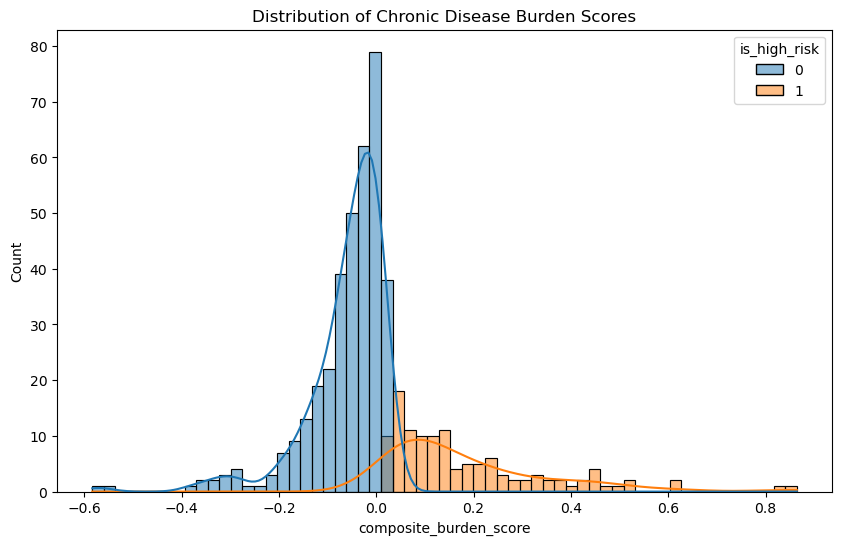

In [ ]:
plt.figure(figsize = (10, 6))
sns.histplot(data = clean_df, x = 'composite_burden_score', hue = 'is_high_risk', kde = True)
plt.title('Distribution of Chronic Disease Burden Scores')
plt.show() # plot looks good

In [ ]:
# See which State/Year has the absolute highest burden
cols_to_show = ['state_abbr', 'state_name', 'yr_start', 'composite_burden_score']

print(clean_df[cols_to_show]
      .sort_values(by = 'composite_burden_score', ascending = False)
      .head(10))

    state_abbr      state_name  yr_start  composite_burden_score
104         WV   West Virginia      2019                0.864204
70          KY        Kentucky      2019                0.824819
367         WV   West Virginia      2021                0.621016
340         MS     Mississippi      2021                0.614831
333         LA       Louisiana      2021                0.527495
78          MS     Mississippi      2019                0.522273
79          MT         Montana      2019                0.499760
71          LA       Louisiana      2019                0.468135
88          OH            Ohio      2019                0.449432
94          SC  South Carolina      2019                0.444774


### Correlation Analysis to See Which Indicators are Pushing States into the High-Risk Category

In [ ]:
# Calculate correlation of all indicators with the burden score
correlations = clean_df.corr(numeric_only = True)['composite_burden_score'].sort_values(ascending = False)

# Look at top 10 strongest drivers of chronic disease risk
print('Top Drivers of High-Risk Scores:')
print(correlations.head(11))

Top Drivers of High-Risk Scores:
composite_burden_score          1.000000
is_high_risk                    0.694989
sdoh__no_broadband_household    0.576065
copd__smoking_copd_adult        0.436773
hs__fair_poor_health_adult      0.422070
arth__activity_limit_arth       0.407052
npaw__soda_ge1_daily_hs         0.398895
npaw__fruit_lt1_daily_adult     0.392631
hs__phys_distress_freq_adult    0.387490
npaw__no_leisure_pa_adult       0.384670
npaw__veg_lt1_daily_hs          0.382310
Name: composite_burden_score, dtype: float64


# Dataset Preparation & Splitting

In [ ]:
X = clean_df.filter(like = '__') # grabs all diesease indicators
y = clean_df['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

print("Class Disribution in Training Set:")
print(y_train.value_counts(normalize = True))

Training set size: 380
Testing set size: 96
Class Disribution in Training Set:
is_high_risk
0    0.75
1    0.25
Name: proportion, dtype: float64


A stratified split was used to ensure the model learns from a balanced representation of high-risk and low-risk cases.

# Supervised Classification
### Models: Logistic Regression, Random Forest, AdaBoost, XGBoost
We compare four classifiers to predict whether a state-year observation falls into the high-risk chronic disease category. Each model is evaluated using stratified 5-fold cross-validation and a held-out test set. Metrics reported include accuracy, precision, recall, F1-score, and ROC-AUC.

### Feature Scaling
Logistic Regression requires scaled features. We apply StandardScaler to X_train and X_test before model training.


In [ ]:
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled  = scaler_clf.transform(X_test)

### Stratified 5-Fold Cross-Validation
A helper function runs stratified 5-fold CV on each model and returns mean ± std for all key metrics. Results are then reported on the held-out test set.

In [ ]:
def evaluate_model_cv(model, X, y, model_name="Model"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    print(f"\n{'='*50}")
    print(f"  {model_name} — 5-Fold CV Results")
    print(f"{'='*50}")
    for metric in scoring:
        scores = results[f'test_{metric}']
        print(f"  {metric.capitalize():12s}: {scores.mean():.4f} ± {scores.std():.4f}")
    return results

### Model 1: Logistic Regression
Serves as the interpretable baseline using L2 regularization.

### Model 2: Random Forest
An ensemble of decision trees using bagging. Handles non-linearity well and provides feature importance scores.

### Model 3: AdaBoost
Sequentially trains weak learners, focusing more weight on previously misclassified samples.

### Model 4: XGBoost
A gradient boosting framework that builds trees sequentially correcting residual errors, with built-in regularization to reduce overfitting.

In [ ]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_cv = evaluate_model_cv(lr, X_train_scaled, y_train, "Logistic Regression")

lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("\nTest Set Classification Report:")
print(classification_report(y_test, lr_pred))


  Logistic Regression — 5-Fold CV Results
  Accuracy    : 0.9158 ± 0.0178
  Precision   : 0.9373 ± 0.0563
  Recall      : 0.7158 ± 0.0788
  F1          : 0.8074 ± 0.0493
  Roc_auc     : 0.9400 ± 0.0270

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        72
           1       0.76      0.79      0.78        24

    accuracy                           0.89        96
   macro avg       0.84      0.85      0.85        96
weighted avg       0.89      0.89      0.89        96



In [ ]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cv = evaluate_model_cv(rf, X_train, y_train, "Random Forest")

rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\nTest Set Classification Report:")
print(classification_report(y_test, rf_pred))


  Random Forest — 5-Fold CV Results
  Accuracy    : 0.8737 ± 0.0244
  Precision   : 0.8515 ± 0.0992
  Recall      : 0.6105 ± 0.0421
  F1          : 0.7083 ± 0.0468
  Roc_auc     : 0.8884 ± 0.0397

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        72
           1       0.68      0.62      0.65        24

    accuracy                           0.83        96
   macro avg       0.78      0.76      0.77        96
weighted avg       0.83      0.83      0.83        96



In [ ]:
#Ada Booster
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_cv = evaluate_model_cv(ada, X_train, y_train, "AdaBoost")

ada.fit(X_train, y_train)
ada_pred  = ada.predict(X_test)
ada_proba = ada.predict_proba(X_test)[:, 1]

print("\nTest Set Classification Report:")
print(classification_report(y_test, ada_pred))


  AdaBoost — 5-Fold CV Results
  Accuracy    : 0.8421 ± 0.0288
  Precision   : 0.6901 ± 0.0673
  Recall      : 0.6842 ± 0.0744
  F1          : 0.6839 ± 0.0538
  Roc_auc     : 0.8752 ± 0.0523

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        72
           1       0.54      0.62      0.58        24

    accuracy                           0.77        96
   macro avg       0.70      0.72      0.71        96
weighted avg       0.78      0.77      0.78        96



In [ ]:
#XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_cv = evaluate_model_cv(xgb, X_train, y_train, "XGBoost")

xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("\nTest Set Classification Report:")
print(classification_report(y_test, xgb_pred))


  XGBoost — 5-Fold CV Results
  Accuracy    : 0.8816 ± 0.0250
  Precision   : 0.8499 ± 0.0728
  Recall      : 0.6421 ± 0.0516
  F1          : 0.7306 ± 0.0550
  Roc_auc     : 0.8872 ± 0.0480

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        72
           1       0.63      0.71      0.67        24

    accuracy                           0.82        96
   macro avg       0.76      0.78      0.77        96
weighted avg       0.83      0.82      0.83        96



### Hyperparameter Tuning
We apply RandomizedSearchCV on Random Forest and GridSearchCV on XGBoost to improve performance. Tuned models are re-evaluated on the test set.

In [ ]:
# --- Random Forest: RandomizedSearchCV ---
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")

# --- XGBoost: GridSearchCV ---
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("\nBest XGB params:", xgb_search.best_params_)
print(f"Best XGB CV AUC: {xgb_search.best_score_:.4f}")

# --- Re-evaluate tuned models on test set ---
best_rf_pred   = best_rf.predict(X_test)
best_rf_proba  = best_rf.predict_proba(X_test)[:, 1]
best_xgb_pred  = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nTuned RF Test Report:")
print(classification_report(y_test, best_rf_pred))
print("\nTuned XGBoost Test Report:")
print(classification_report(y_test, best_xgb_pred))

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
Best RF CV AUC: 0.8940

Best XGB params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best XGB CV AUC: 0.8962

Tuned RF Test Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        72
           1       0.71      0.62      0.67        24

    accuracy                           0.84        96
   macro avg       0.80      0.77      0.78        96
weighted avg       0.84      0.84      0.84        96


Tuned XGBoost Test Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        72
           1       0.65      0.71      0.68        24

    accuracy                           0.83        96
   macro avg       0.78      0.79      0.78        96
weighted avg       0.84      0.83      0.84        96



### Model Evaluation: ROC Curves, Confusion Matrices & Feature Importance
ROC-AUC curves compare all four models on the held-out test set. Confusion matrices show the breakdown of predictions. Feature importance plots highlight the strongest predictors from the two best-performing ensemble models.

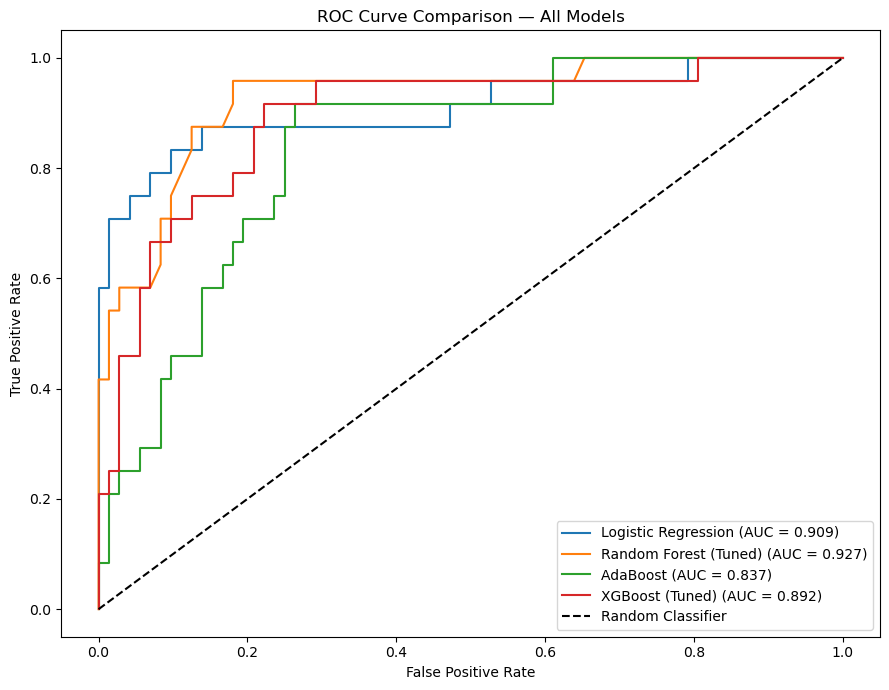

In [ ]:
#ROC Curves
models_roc = {
    'Logistic Regression': lr_proba,
    'Random Forest (Tuned)': best_rf_proba,
    'AdaBoost': ada_proba,
    'XGBoost (Tuned)': best_xgb_proba
}

plt.figure(figsize=(9, 7))
for name, proba in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

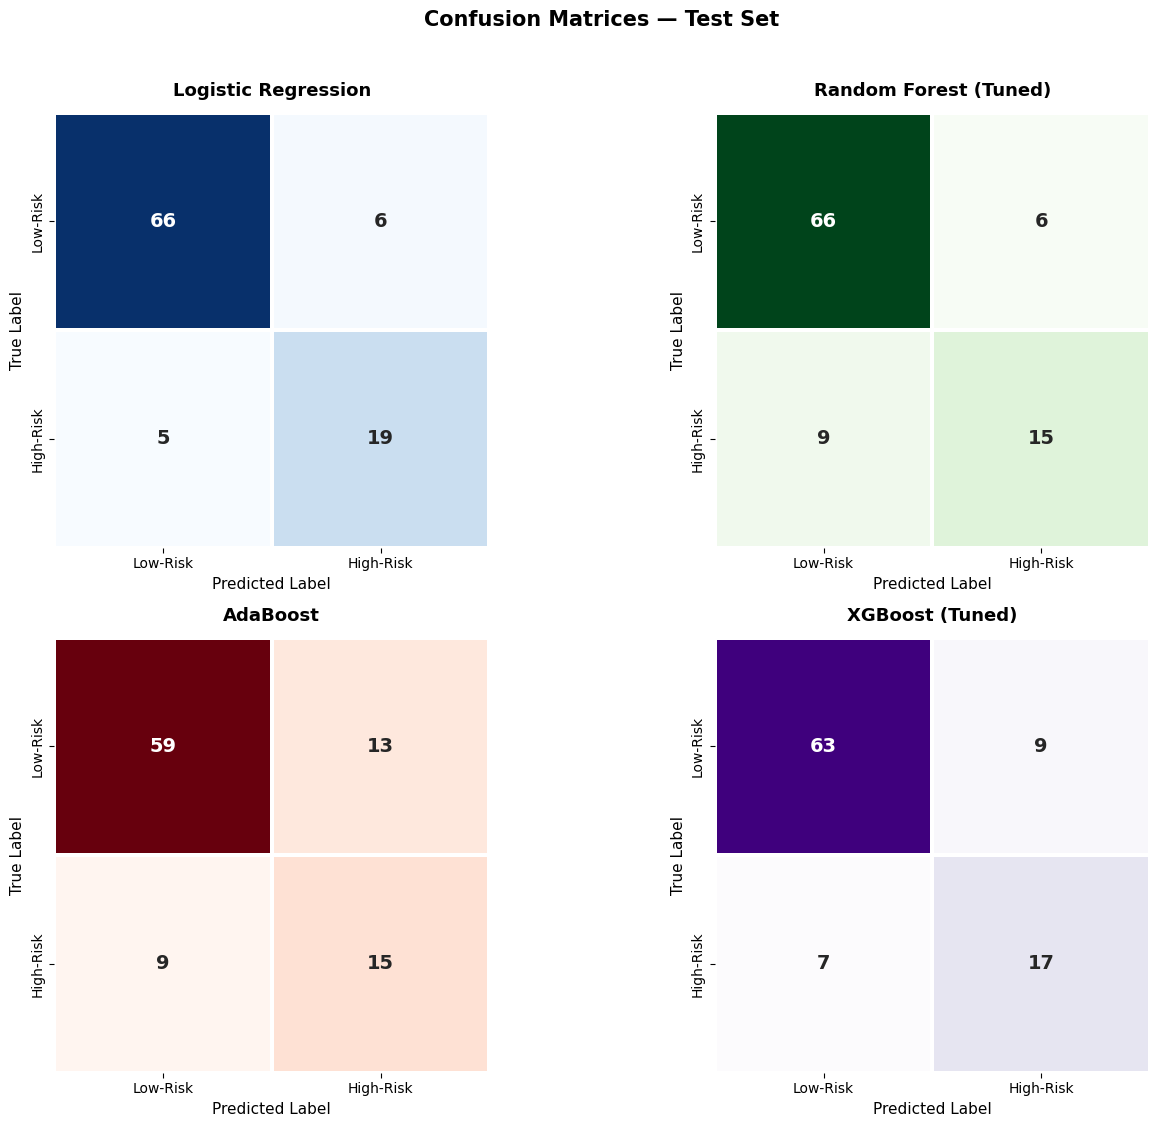

In [ ]:
#Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

models_cm = {
    'Logistic Regression': (lr_pred, axes[0, 0], 'Blues'),
    'Random Forest (Tuned)': (best_rf_pred, axes[0, 1], 'Greens'),
    'AdaBoost': (ada_pred, axes[1, 0], 'Reds'),
    'XGBoost (Tuned)': (best_xgb_pred, axes[1, 1], 'Purples')
}

for name, (pred, ax, cmap) in models_cm.items():
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        linewidths=1.5,
        linecolor='white',
        square=True,
        cbar=False,
        ax=ax,
        xticklabels=['Low-Risk', 'High-Risk'],
        yticklabels=['Low-Risk', 'High-Risk'],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(name, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

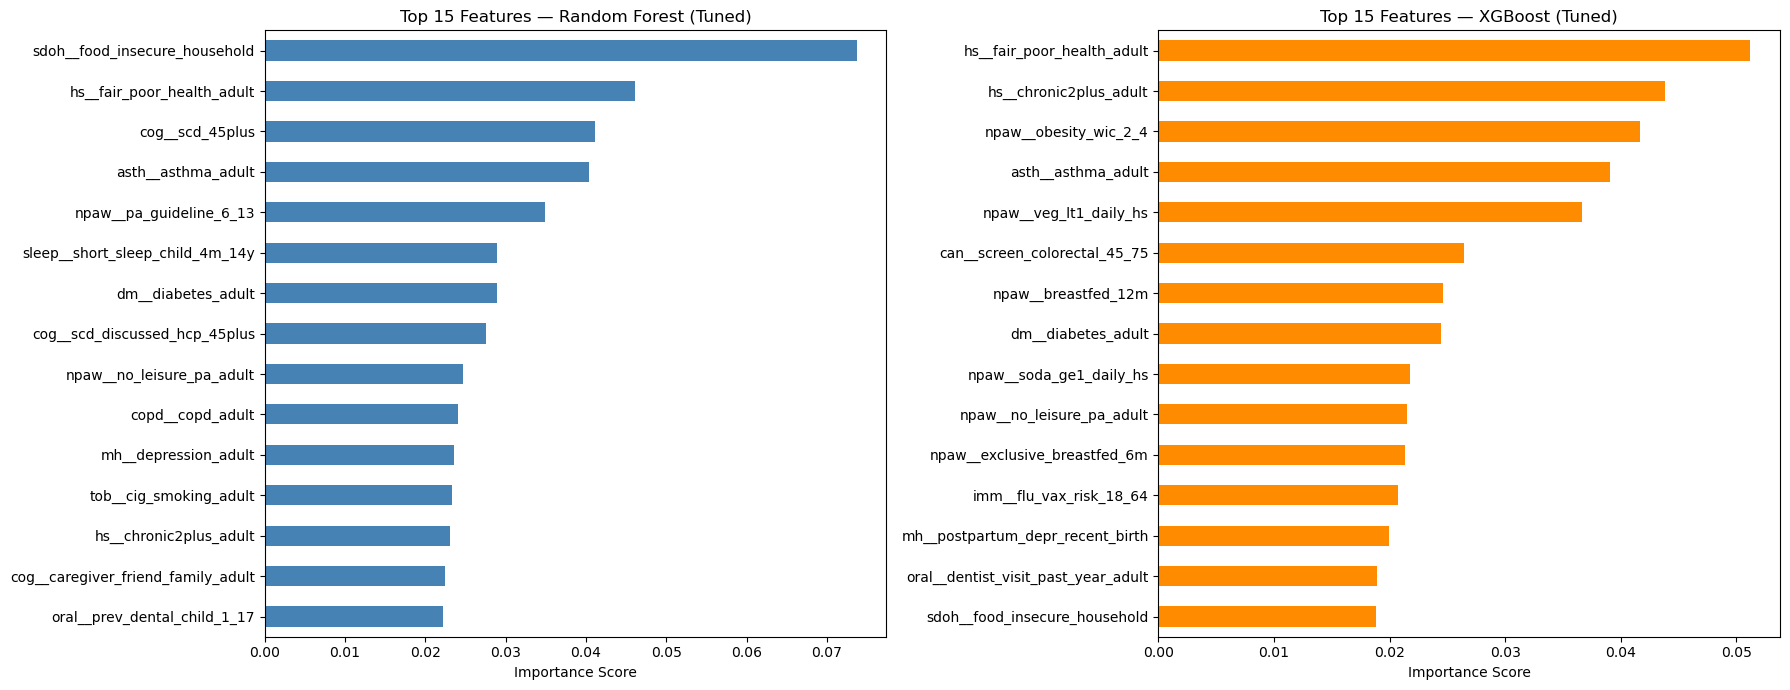

In [ ]:
#Feature Importance
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

rf_importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
rf_importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features — Random Forest (Tuned)')
axes[0].set_xlabel('Importance Score')

xgb_importances = pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
xgb_importances.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Features — XGBoost (Tuned)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [ ]:
summary_data = {
    'Model': ['Logistic Regression', 'Random Forest (Tuned)', 'AdaBoost', 'XGBoost (Tuned)'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, best_rf_pred),
                  accuracy_score(y_test, ada_pred),
                  accuracy_score(y_test, best_xgb_pred)],
    'Precision': [precision_score(y_test, lr_pred),
                  precision_score(y_test, best_rf_pred),
                  precision_score(y_test, ada_pred),
                  precision_score(y_test, best_xgb_pred)],
    'Recall':    [recall_score(y_test, lr_pred),
                  recall_score(y_test, best_rf_pred),
                  recall_score(y_test, ada_pred),
                  recall_score(y_test, best_xgb_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),
                  f1_score(y_test, best_rf_pred),
                  f1_score(y_test, ada_pred),
                  f1_score(y_test, best_xgb_pred)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),
                  roc_auc_score(y_test, best_rf_proba),
                  roc_auc_score(y_test, ada_proba),
                  roc_auc_score(y_test, best_xgb_proba)]
}

summary_df = pd.DataFrame(summary_data).set_index('Model').round(4)
display(summary_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8854,0.7600,0.7917,0.7755,0.9091
Random Forest (Tuned),0.8438,0.7143,0.6250,0.6667,0.9268
AdaBoost,0.7708,0.5357,0.6250,0.5769,0.8374
XGBoost (Tuned),0.8333,0.6538,0.7083,0.6800,0.8918


# Unsupervised Clustering
### Methods: K-Means and DBSCAN
Clustering is applied to the full scaled feature matrix to identify natural groupings of state-year observations based on chronic disease and behavioral profiles; independent of the high-risk label. Internal validation uses Silhouette Score and Davies-Bouldin Index. Clusters are visualized via PCA 2D projection and profiled by their top indicator patterns.

In [29]:
#PCA Setup
# Use the full dataset scaled consistently

# Collect unique year pairs
unique_year_pairs = clean_df[['yr_start', 'yr_end']].drop_duplicates().values

# Dictionaries to store PCA results for each year pair
all_X_pca_results = {}
all_pca_objects = {}
all_explained_variances = {}

print("Performing PCA for each unique (yr_start, yr_end) pair:")
for yr_start_val, yr_end_val in unique_year_pairs:
    current_X_all = clean_df[(clean_df['yr_start'] == yr_start_val) & (clean_df['yr_end'] == yr_end_val)]
    # Filter for indicator columns
    current_X_all = current_X_all.filter(like='__')
    # Drop columns that have any NaN values for this specific year group.
    # While clean_df should have been largely imputed, this ensures robustness for PCA if any NaNs remain in specific year groups.
    current_X_all = current_X_all.dropna(axis=1)

    # Ensure enough samples and features for PCA
    if not current_X_all.empty and current_X_all.shape[0] > 1 and current_X_all.shape[1] >= 2:
        pca_temp = PCA(n_components=2, random_state=42)
        X_pca_temp = pca_temp.fit_transform(current_X_all)
        explained_variance = pca_temp.explained_variance_ratio_.sum()

        all_X_pca_results[(yr_start_val, yr_end_val)] = X_pca_temp
        all_pca_objects[(yr_start_val, yr_end_val)] = pca_temp
        all_explained_variances[(yr_start_val, yr_end_val)] = explained_variance

        print(f"  Year Pair ({yr_start_val}, {yr_end_val}): Explained variance by 2 PCs: {explained_variance:.2%}")
    else:
        print(f"  Year Pair ({yr_start_val}, {yr_end_val}): Not enough valid data (rows > 1 and cols >= 2) for PCA (shape: {current_X_all.shape}). Skipping.")



Performing PCA for each unique (yr_start, yr_end) pair:
  Year Pair (2018, 2019): Explained variance by 2 PCs: 68.97%
  Year Pair (2019, 2019): Explained variance by 2 PCs: 26.01%
  Year Pair (2019, 2020): Explained variance by 2 PCs: 100.00%
  Year Pair (2019, 2021): Not enough valid data (rows > 1 and cols >= 2) for PCA (shape: (52, 1)). Skipping.
  Year Pair (2020, 2020): Explained variance by 2 PCs: 28.18%
  Year Pair (2020, 2021): Explained variance by 2 PCs: 67.46%
  Year Pair (2021, 2021): Explained variance by 2 PCs: 29.14%
  Year Pair (2021, 2022): Explained variance by 2 PCs: 100.00%
  Year Pair (2022, 2022): Explained variance by 2 PCs: 31.65%


### K-Means Clustering
The Elbow Method and Silhouette Score are used to select the optimal number of clusters k, then the final model is fit and evaluated.

Running K-Means for each PCA year pair:


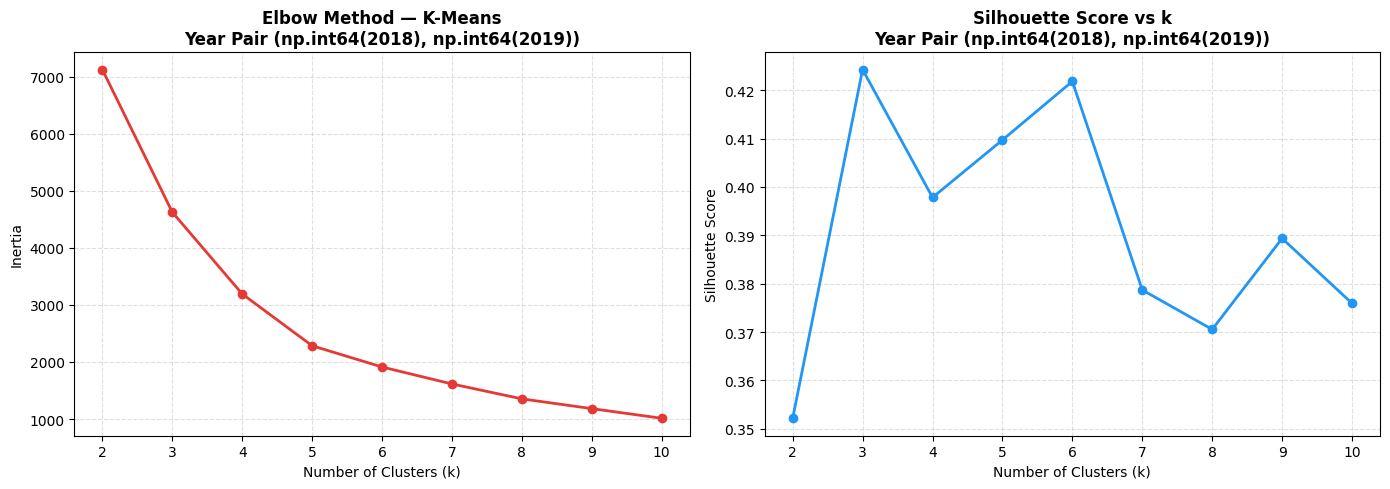

Year Pair (np.int64(2018), np.int64(2019)) | Optimal k: 3
K-Means | Silhouette: 0.4243 | Davies-Bouldin: 0.7703
------------------------------------------------------------


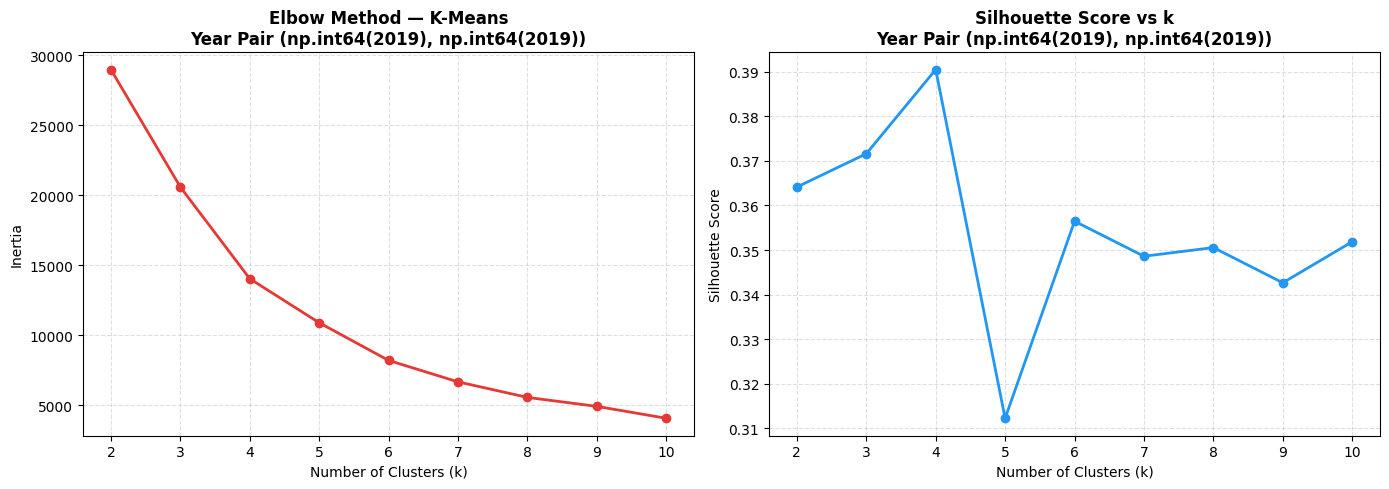

Year Pair (np.int64(2019), np.int64(2019)) | Optimal k: 4
K-Means | Silhouette: 0.3905 | Davies-Bouldin: 0.6578
------------------------------------------------------------


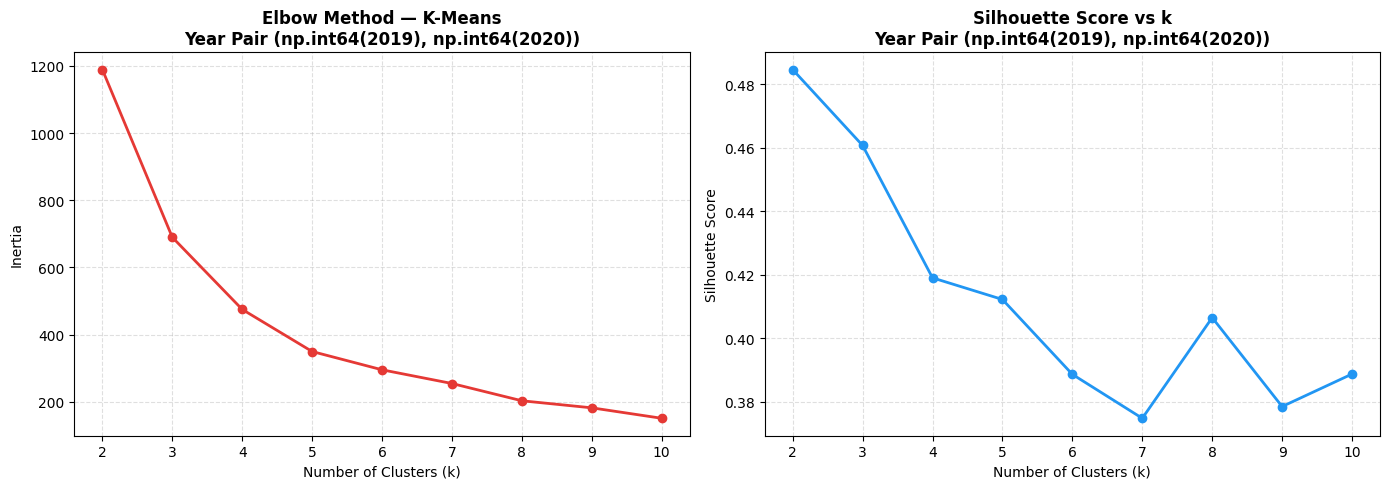

Year Pair (np.int64(2019), np.int64(2020)) | Optimal k: 2
K-Means | Silhouette: 0.4846 | Davies-Bouldin: 0.7233
------------------------------------------------------------


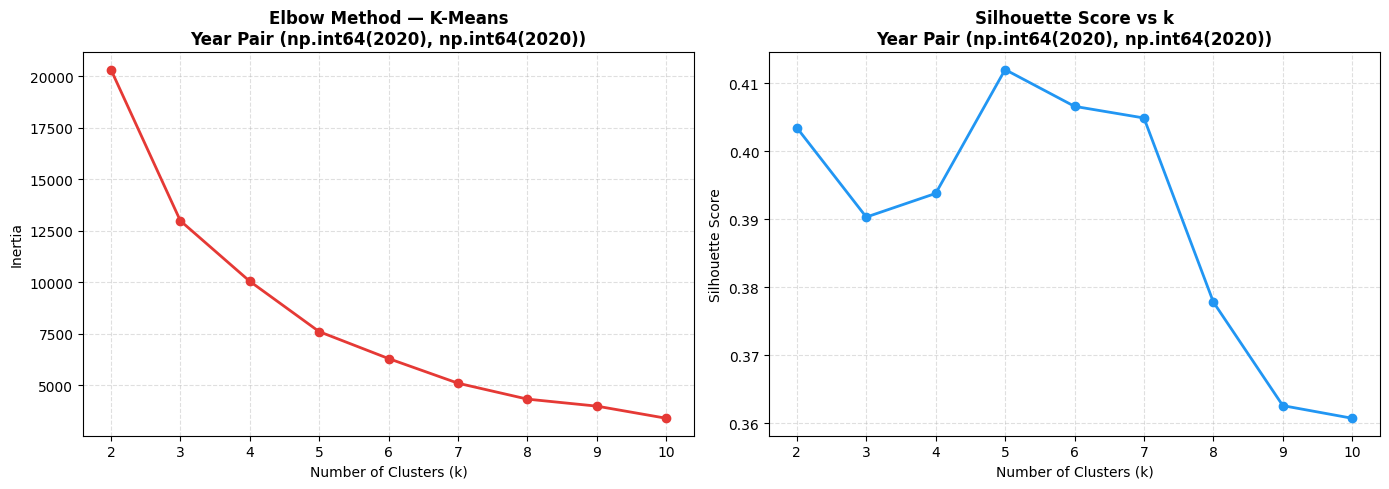

Year Pair (np.int64(2020), np.int64(2020)) | Optimal k: 5
K-Means | Silhouette: 0.4120 | Davies-Bouldin: 0.7585
------------------------------------------------------------


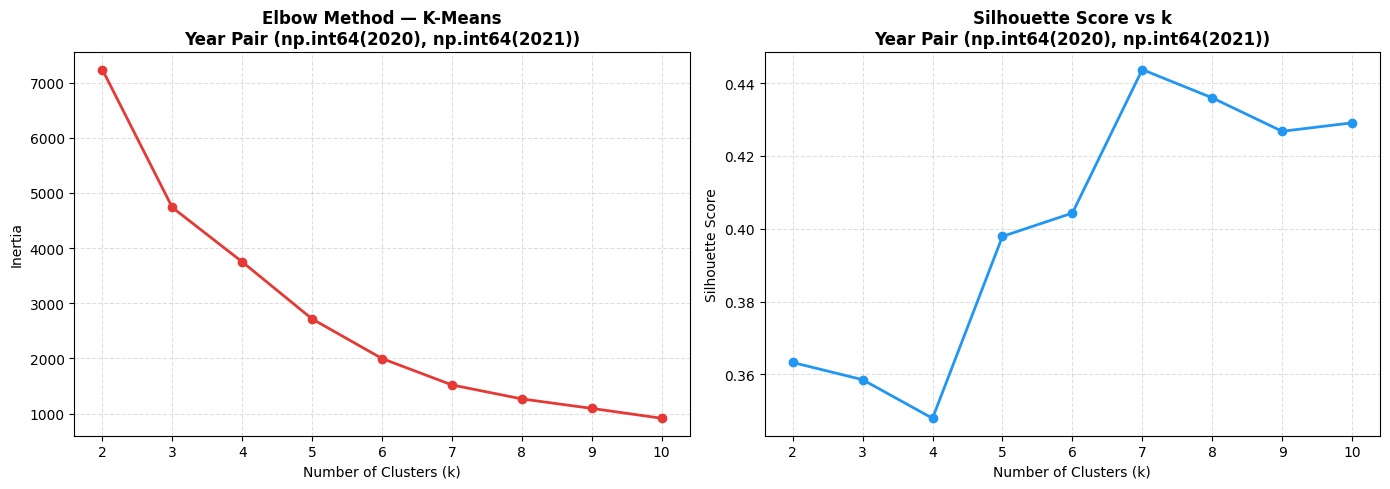

Year Pair (np.int64(2020), np.int64(2021)) | Optimal k: 7
K-Means | Silhouette: 0.4437 | Davies-Bouldin: 0.6655
------------------------------------------------------------


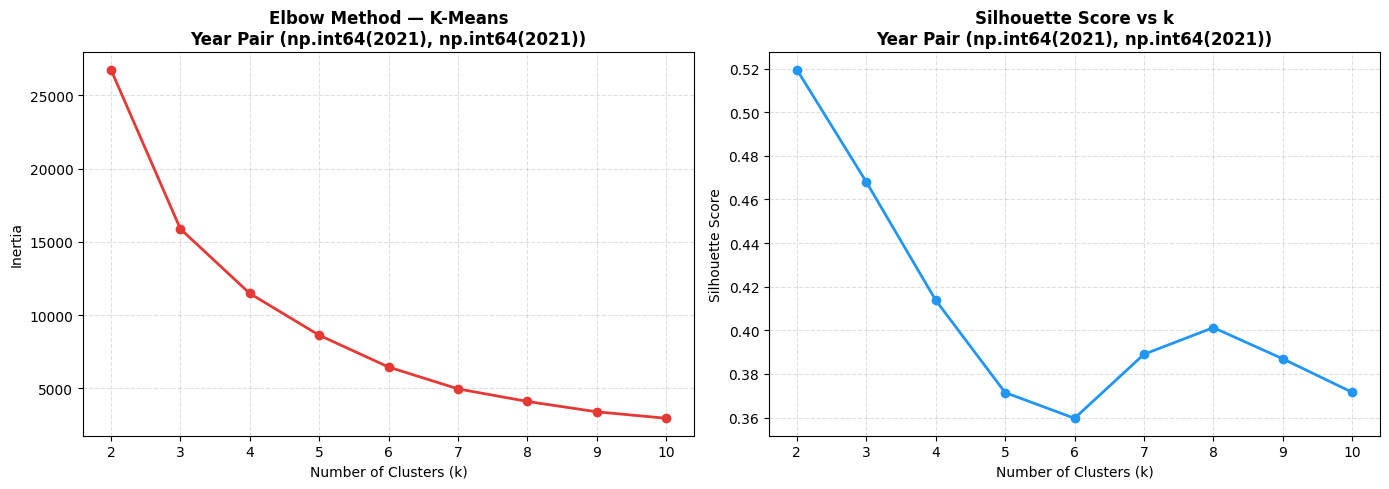

Year Pair (np.int64(2021), np.int64(2021)) | Optimal k: 2
K-Means | Silhouette: 0.5196 | Davies-Bouldin: 0.7844
------------------------------------------------------------


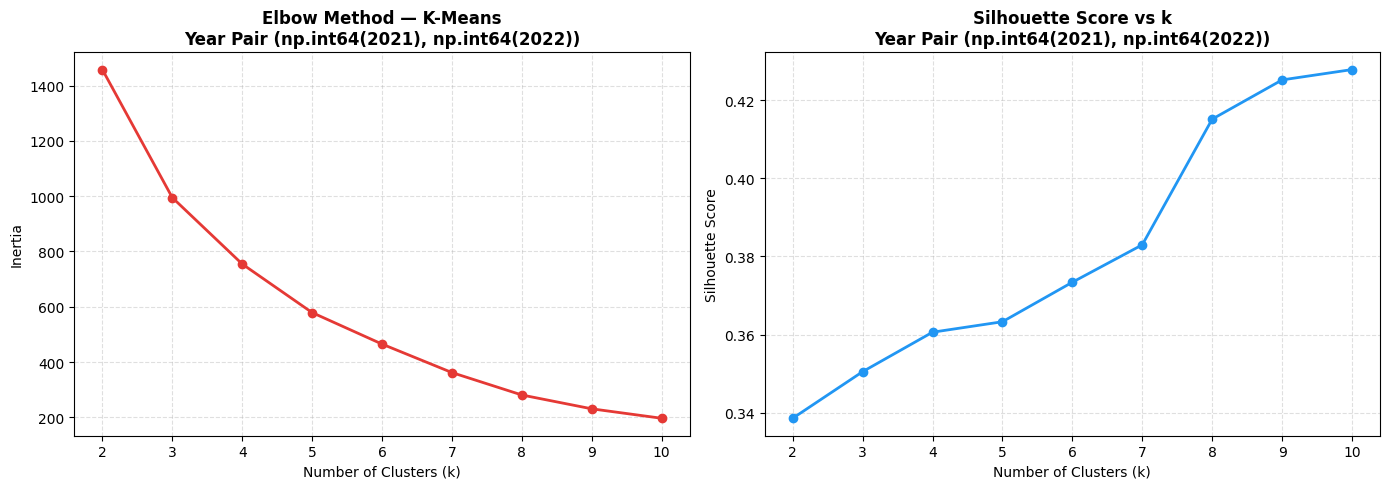

Year Pair (np.int64(2021), np.int64(2022)) | Optimal k: 10
K-Means | Silhouette: 0.4278 | Davies-Bouldin: 0.6849
------------------------------------------------------------


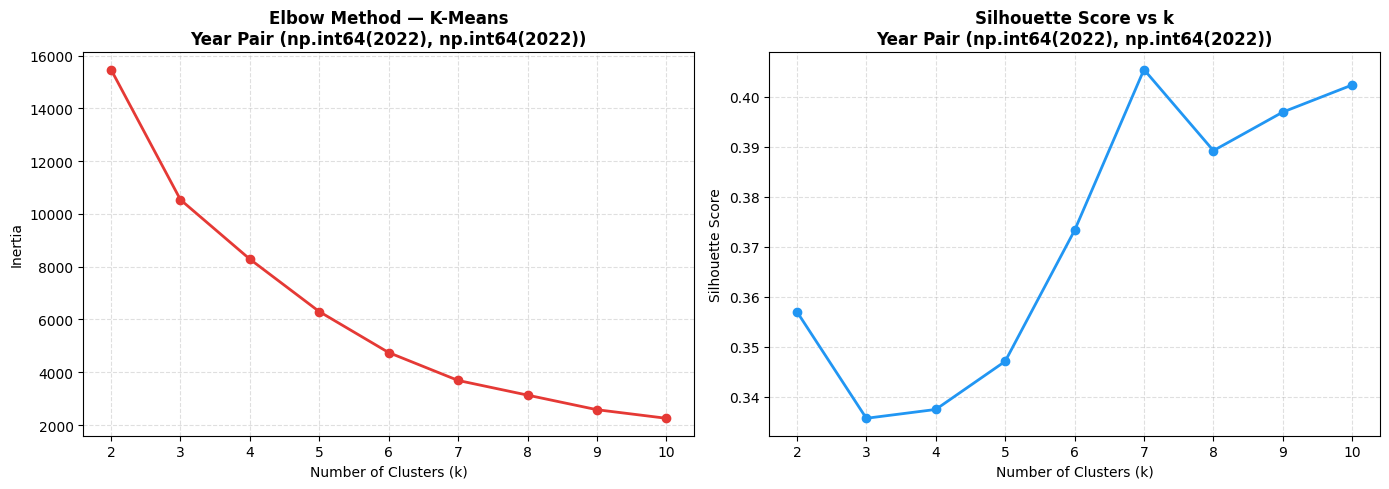

Year Pair (np.int64(2022), np.int64(2022)) | Optimal k: 7
K-Means | Silhouette: 0.4055 | Davies-Bouldin: 0.7449
------------------------------------------------------------


In [30]:
# Dictionaries to store clustering outputs for each year pair
all_inertias = {}
all_sil_scores = {}
all_best_k = {}
all_kmeans_labels = {}
all_kmeans_models = {}
all_kmeans_metrics = {}

print("Running K-Means for each PCA year pair:")

for year_pair, X_all in all_X_pca_results.items():
    n_samples = X_all.shape[0]

    # Need at least 3 samples for clustering with k >= 2
    if n_samples < 3:
        print(f"Year Pair {year_pair}: Not enough samples for clustering (n={n_samples}). Skipping.")
        continue

    # Adaptive k range
    max_k = min(10, n_samples - 1)
    if max_k < 2:
        print(f"Year Pair {year_pair}: max_k < 2. Skipping.")
        continue

    k_range = range(2, max_k + 1)
    inertias = []
    sil_scores = []

    # Compute clustering metrics across k
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_all)

        inertias.append(km.inertia_)

        # silhouette requires at least 2 clusters and fewer clusters than samples
        if len(np.unique(labels)) > 1 and len(np.unique(labels)) < n_samples:
            sil_scores.append(silhouette_score(X_all, labels))
        else:
            sil_scores.append(np.nan)

    # Store curves
    all_inertias[year_pair] = inertias
    all_sil_scores[year_pair] = sil_scores

    # Plot for this year pair
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(k_range, inertias, marker='o', color='#E53935', linewidth=2)
    axes[0].set_title(f'Elbow Method — K-Means\nYear Pair {year_pair}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(k_range, sil_scores, marker='o', color='#2196F3', linewidth=2)
    axes[1].set_title(f'Silhouette Score vs k\nYear Pair {year_pair}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # Choose best k based on silhouette
    valid_sil = [s for s in sil_scores if not np.isnan(s)]
    if len(valid_sil) == 0:
        print(f"Year Pair {year_pair}: No valid silhouette scores. Skipping final K-Means.")
        continue

    best_idx = int(np.nanargmax(sil_scores))
    best_k = list(k_range)[best_idx]
    all_best_k[year_pair] = best_k

    # Final KMeans for this year pair
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    km_sil = silhouette_score(X_all, km_labels)
    km_db = davies_bouldin_score(X_all, km_labels)

    all_kmeans_labels[year_pair] = km_labels
    all_kmeans_models[year_pair] = km_final
    all_kmeans_metrics[year_pair] = {
        'best_k': best_k,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"Year Pair {year_pair} | Optimal k: {best_k}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)

In [32]:
# Dictionaries to store clustering outputs for each year pair
all_inertias = {}
all_sil_scores = {}
all_best_k = {}
all_kmeans_labels = {}
all_kmeans_models = {}
all_kmeans_metrics = {}

# Set your desired manual K value here
# For example, manual_k = 3, manual_k = 5, etc.
manual_k_value = 5 # You can change this value as needed

print(f"Running K-Means for each PCA year pair with manual k = {manual_k_value}:")

for year_pair, X_all in all_X_pca_results.items():
    n_samples = X_all.shape[0]

    # Need at least 'manual_k_value' samples for clustering
    if n_samples < manual_k_value:
        print(f"Year Pair {year_pair}: Not enough samples for clustering with k={manual_k_value} (n={n_samples}). Skipping.")
        continue

    # K-Means with the manual K value
    km_final = KMeans(n_clusters=manual_k_value, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    # Evaluate the clustering
    # silhouette requires at least 2 clusters and fewer clusters than samples
    if len(np.unique(km_labels)) > 1 and len(np.unique(km_labels)) < n_samples:
        km_sil = silhouette_score(X_all, km_labels)
        km_db = davies_bouldin_score(X_all, km_labels)
    else:
        km_sil = np.nan
        km_db = np.nan

    # Store results
    all_kmeans_labels[year_pair] = km_labels
    all_kmeans_models[year_pair] = km_final
    all_best_k[year_pair] = manual_k_value # Storing the manual K value
    all_kmeans_metrics[year_pair] = {
        'best_k': manual_k_value,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"Year Pair {year_pair} | Manual k: {manual_k_value}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)

Running K-Means for each PCA year pair with manual k = 5:
Year Pair (np.int64(2018), np.int64(2019)) | Manual k: 5
K-Means | Silhouette: 0.4097 | Davies-Bouldin: 0.7104
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2019)) | Manual k: 5
K-Means | Silhouette: 0.3123 | Davies-Bouldin: 0.8307
------------------------------------------------------------
Year Pair (np.int64(2019), np.int64(2020)) | Manual k: 5
K-Means | Silhouette: 0.4122 | Davies-Bouldin: 0.7563
------------------------------------------------------------
Year Pair (np.int64(2020), np.int64(2020)) | Manual k: 5
K-Means | Silhouette: 0.4120 | Davies-Bouldin: 0.7585
------------------------------------------------------------
Year Pair (np.int64(2020), np.int64(2021)) | Manual k: 5
K-Means | Silhouette: 0.3979 | Davies-Bouldin: 0.7991
------------------------------------------------------------
Year Pair (np.int64(2021), np.int64(2021)) | Manual k: 5
K-Means | Silhouette: 0.3

### DBSCAN Clustering
DBSCAN identifies clusters of arbitrary shape and marks low-density observations as noise (label = −1). Epsilon and min_samples are tuned via a parameter sweep maximizing silhouette score.

Running DBSCAN for each PCA year pair:
Year Pair (np.int64(2018), np.int64(2019)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 4 | Noise points: 37
DBSCAN | Silhouette: 0.6626 | Davies-Bouldin: 0.3975
------------------------------------------------------------


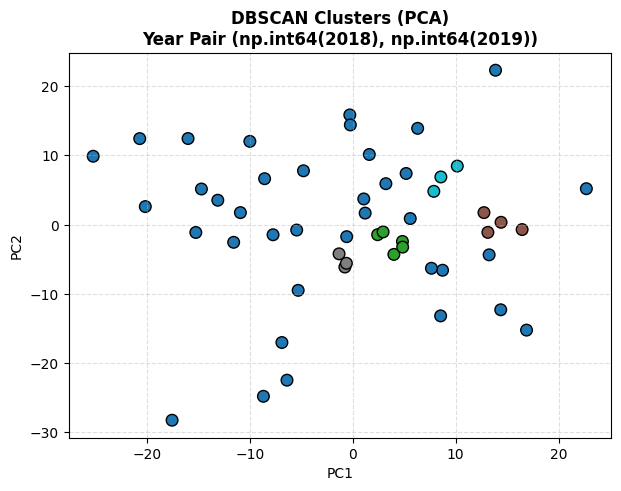

Year Pair (np.int64(2019), np.int64(2019)): No valid DBSCAN clustering found.
Year Pair (np.int64(2019), np.int64(2020)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 3 | Noise points: 10
DBSCAN | Silhouette: 0.3985 | Davies-Bouldin: 0.6056
------------------------------------------------------------


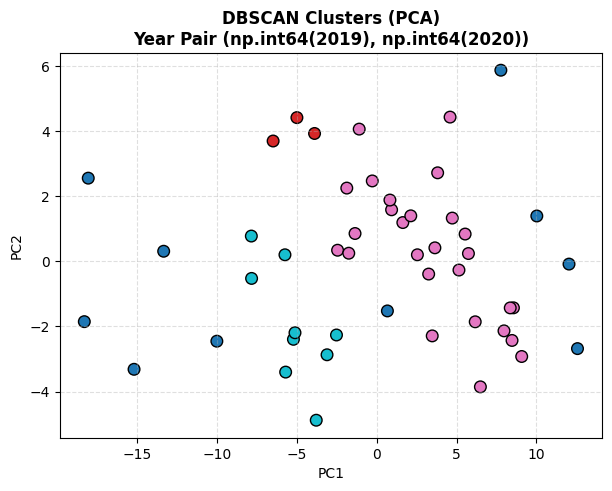

Year Pair (np.int64(2020), np.int64(2020)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 2 | Noise points: 48
DBSCAN | Silhouette: 0.7808 | Davies-Bouldin: 0.2558
------------------------------------------------------------


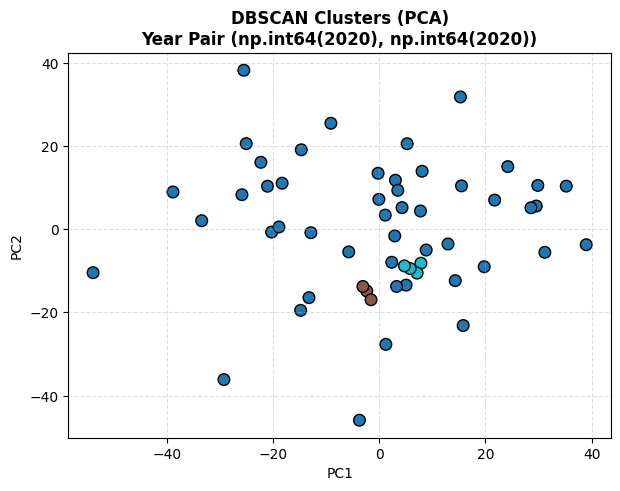

Year Pair (np.int64(2020), np.int64(2021)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 3 | Noise points: 40
DBSCAN | Silhouette: 0.6138 | Davies-Bouldin: 0.3909
------------------------------------------------------------


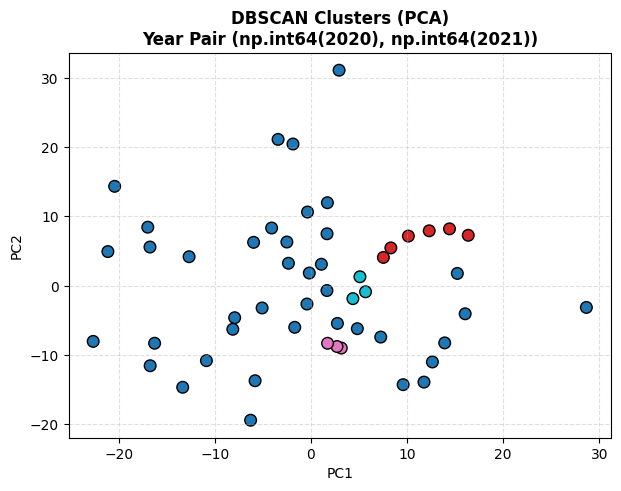

Year Pair (np.int64(2021), np.int64(2021)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 4 | Noise points: 42
DBSCAN | Silhouette: 0.7565 | Davies-Bouldin: 0.3059
------------------------------------------------------------


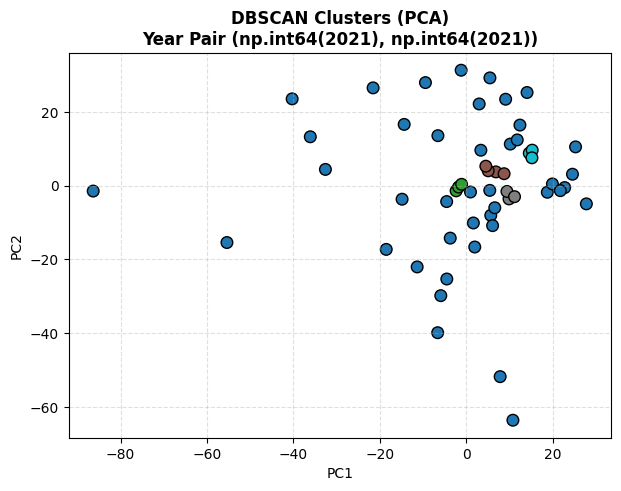

Year Pair (np.int64(2021), np.int64(2022)) | Best eps=2.5, min_samples=3
DBSCAN clusters: 4 | Noise points: 13
DBSCAN | Silhouette: 0.4494 | Davies-Bouldin: 0.6822
------------------------------------------------------------


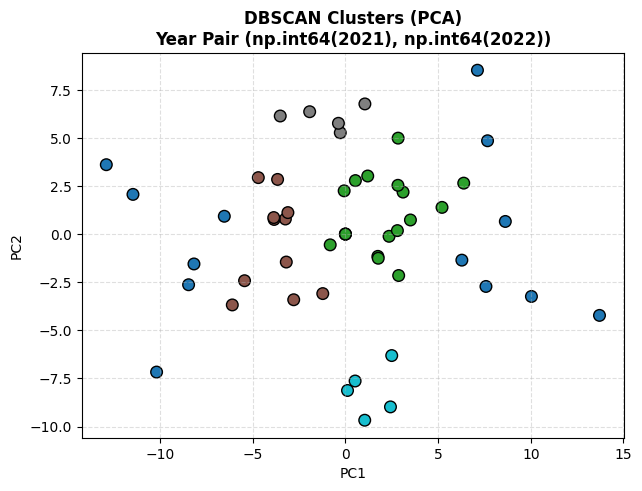

Year Pair (np.int64(2022), np.int64(2022)): No valid DBSCAN clustering found.


In [31]:
# Store results
all_dbscan_params = {}
all_dbscan_labels = {}
all_dbscan_metrics = {}

print("Running DBSCAN for each PCA year pair:")

for year_pair, X_all in all_X_pca_results.items():
    n_samples = X_all.shape[0]

    if n_samples < 5:
        print(f"Year Pair {year_pair}: Not enough samples for DBSCAN (n={n_samples}). Skipping.")
        continue

    best_sil_db = -1
    best_eps = None
    best_min_samp = None
    best_labels = None

    # Parameter grid (can be tuned further)
    eps_values = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5]
    min_samples_values = [3, 5, 7, 10]

    for eps, min_s in product(eps_values, min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_all)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Need at least 2 clusters for silhouette
        if n_clusters >= 2:
            try:
                sil = silhouette_score(X_all, labels)
                if sil > best_sil_db:
                    best_sil_db = sil
                    best_eps = eps
                    best_min_samp = min_s
                    best_labels = labels
            except:
                continue

    # If no valid clustering found
    if best_labels is None:
        print(f"Year Pair {year_pair}: No valid DBSCAN clustering found.")
        continue

    # Final model with best params
    db_final = DBSCAN(eps=best_eps, min_samples=best_min_samp)
    db_labels = db_final.fit_predict(X_all)

    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise_db = list(db_labels).count(-1)

    print(f"Year Pair {year_pair} | Best eps={best_eps}, min_samples={best_min_samp}")
    print(f"DBSCAN clusters: {n_clusters_db} | Noise points: {n_noise_db}")

    # Evaluate only non-noise points
    non_noise = db_labels != -1

    if non_noise.sum() > 0 and len(set(db_labels[non_noise])) >= 2:
        db_sil = silhouette_score(X_all[non_noise], db_labels[non_noise])
        db_db = davies_bouldin_score(X_all[non_noise], db_labels[non_noise])

        print(f"DBSCAN | Silhouette: {db_sil:.4f} | Davies-Bouldin: {db_db:.4f}")

        all_dbscan_metrics[year_pair] = {
            'eps': best_eps,
            'min_samples': best_min_samp,
            'n_clusters': n_clusters_db,
            'noise_points': n_noise_db,
            'silhouette': db_sil,
            'davies_bouldin': db_db
        }
    else:
        print("DBSCAN: insufficient clusters for evaluation.")
        all_dbscan_metrics[year_pair] = {
            'eps': best_eps,
            'min_samples': best_min_samp,
            'n_clusters': n_clusters_db,
            'noise_points': n_noise_db,
            'silhouette': None,
            'davies_bouldin': None
        }

    all_dbscan_labels[year_pair] = db_labels
    all_dbscan_params[year_pair] = (best_eps, best_min_samp)

    print("-" * 60)

    # 🔹 Optional: Visualization
    plt.figure(figsize=(7, 5))
    plt.scatter(X_all[:, 0], X_all[:, 1], c=db_labels, cmap='tab10', s=70, edgecolor='k')
    plt.title(f'DBSCAN Clusters (PCA)\nYear Pair {year_pair}',
              fontsize=12, fontweight='bold')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

### Cluster Visualization & Profiling
Observations are projected onto 2 principal components and colored by cluster. K-Means clusters are then profiled by the top indicators that vary most across groups.

Year Pair (np.int64(2018), np.int64(2019)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


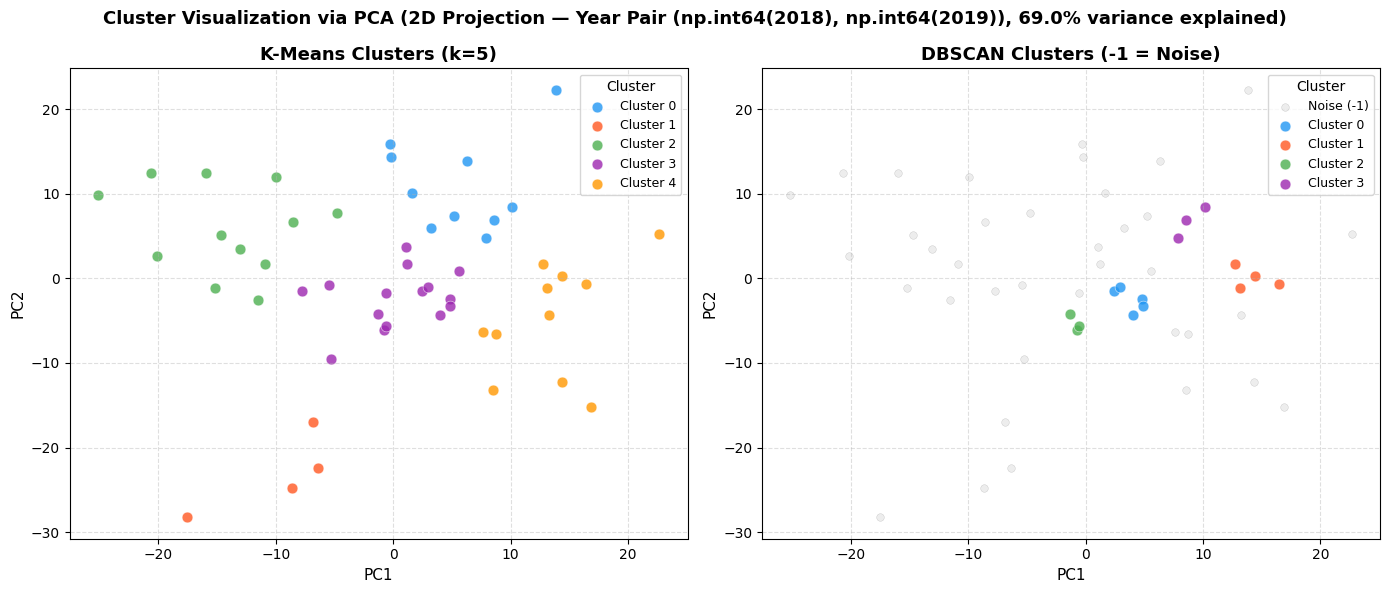

Year Pair (np.int64(2019), np.int64(2019)): missing K-Means or DBSCAN results. Skipping plot.
Year Pair (np.int64(2019), np.int64(2020)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


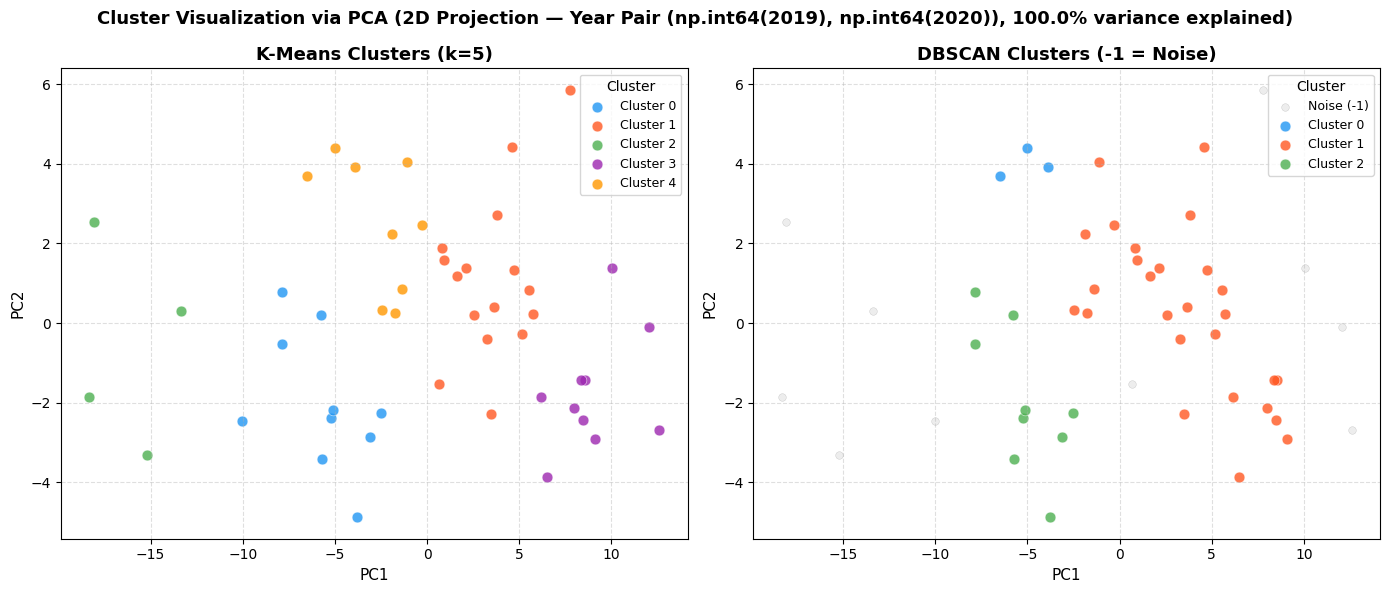

Year Pair (np.int64(2020), np.int64(2020)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


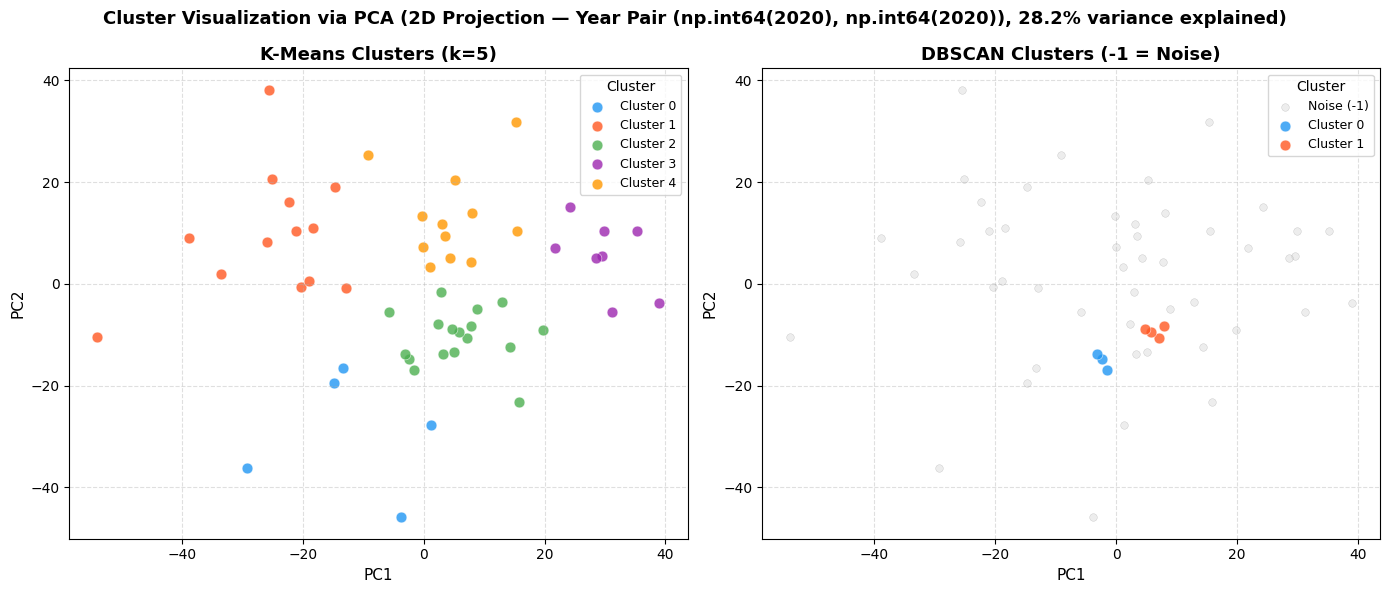

Year Pair (np.int64(2020), np.int64(2021)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


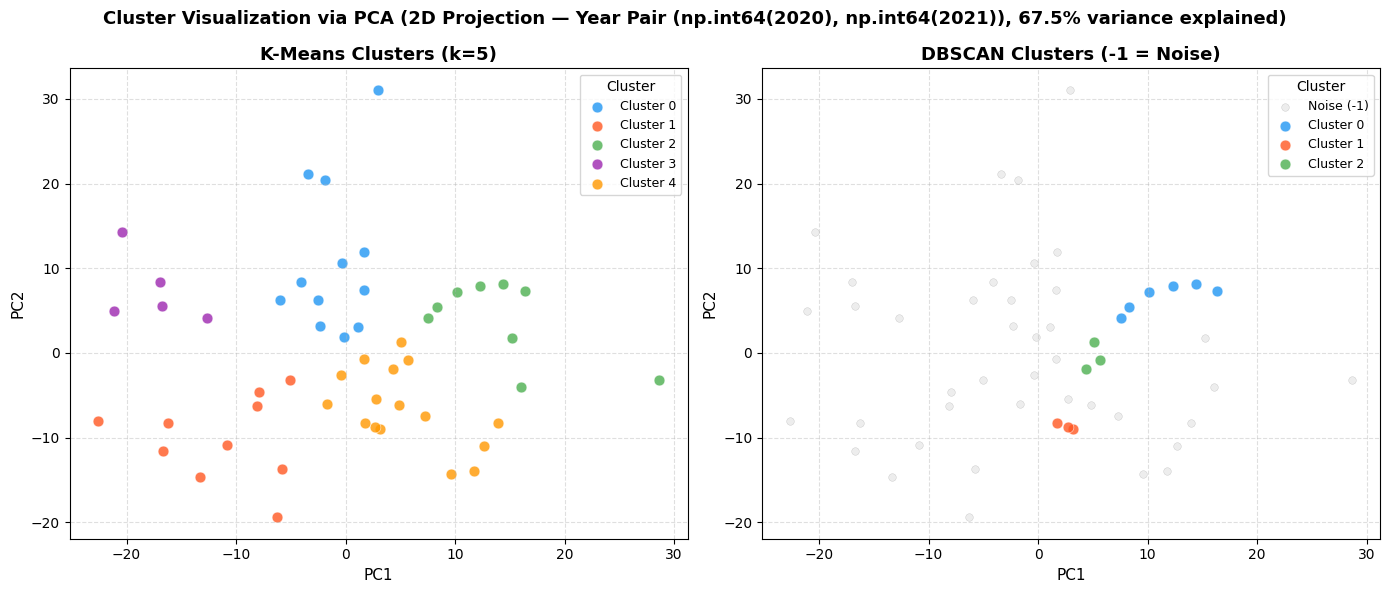

Year Pair (np.int64(2021), np.int64(2021)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


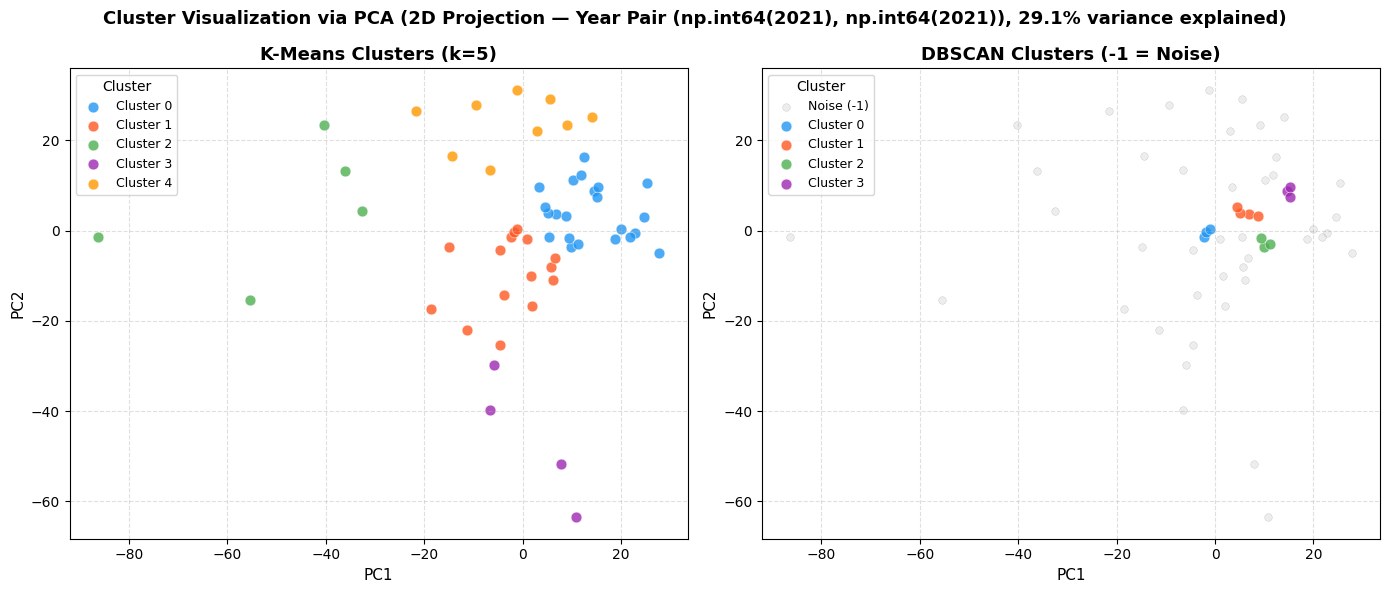

Year Pair (np.int64(2021), np.int64(2022)): 'risk_label' column not found. Plotting only K-Means and DBSCAN.


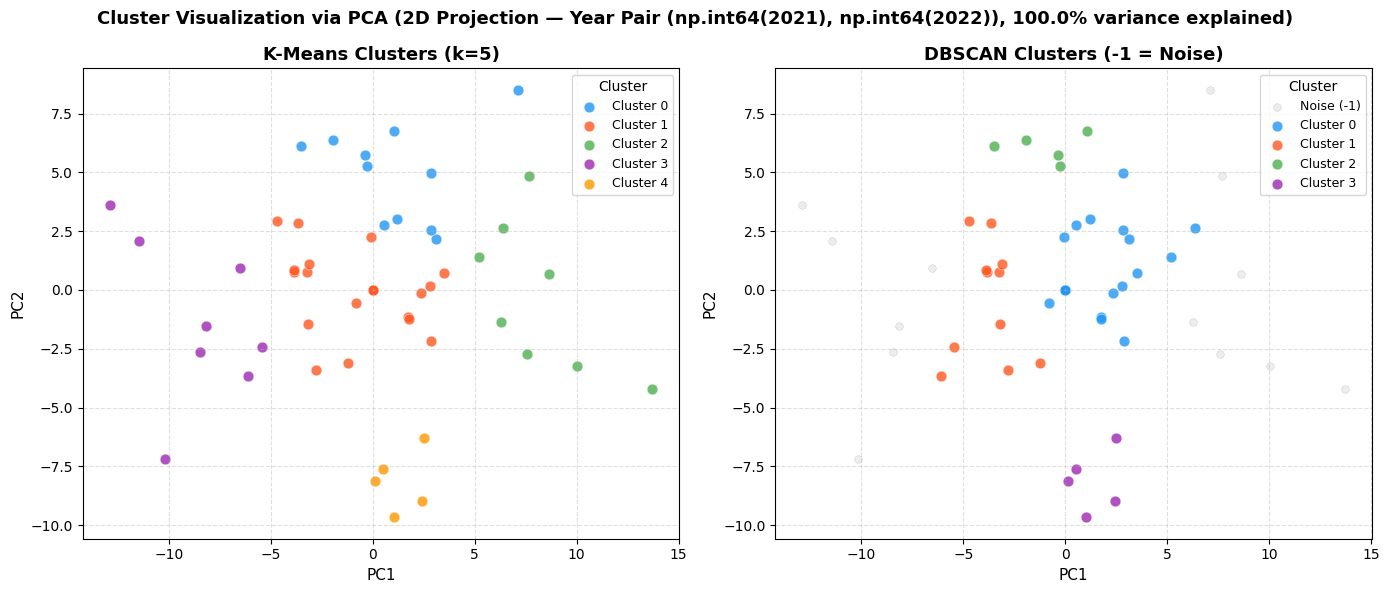

Year Pair (np.int64(2022), np.int64(2022)): missing K-Means or DBSCAN results. Skipping plot.


In [33]:
for year_pair, X_pca in all_X_pca_results.items():
    yr_start_val, yr_end_val = year_pair

    # Skip if clustering results do not exist
    if year_pair not in all_kmeans_labels or year_pair not in all_dbscan_labels:
        print(f"Year Pair {year_pair}: missing K-Means or DBSCAN results. Skipping plot.")
        continue

    km_labels = all_kmeans_labels[year_pair]
    db_labels = all_dbscan_labels[year_pair]
    best_k = all_best_k.get(year_pair, None)
    explained_var = all_explained_variances.get(year_pair, np.nan)

    # Recreate the same subset/order used for PCA so labels align correctly
    current_df = clean_df[
        (clean_df['yr_start'] == yr_start_val) &
        (clean_df['yr_end'] == yr_end_val)
    ].copy()

    current_X_all = current_df.filter(like='__')
    current_X_all = current_X_all.dropna(axis=1)

    # If your risk label column exists in clean_df, change 'risk_label' below if needed
    if 'risk_label' not in current_df.columns:
        print(f"Year Pair {year_pair}: 'risk_label' column not found. Plotting only K-Means and DBSCAN.")
        plot_ground_truth = False
    else:
        risk_labels = current_df['risk_label'].reset_index(drop=True).values
        plot_ground_truth = True

    # Safety check: make sure lengths match
    if len(current_X_all) != len(X_pca):
        print(f"Year Pair {year_pair}: mismatch between PCA rows and current data rows. Skipping.")
        continue

    n_panels = 3 if plot_ground_truth else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(20 if plot_ground_truth else 14, 6))

    if n_panels == 2:
        axes = np.array(axes)  # keep indexing consistent

    # --- Panel 1: K-Means clusters ---
    km_unique = np.unique(km_labels)
    km_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
                  '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

    for i, label in enumerate(km_unique):
        mask = km_labels == label
        color = km_palette[i % len(km_palette)]
        axes[0].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=color, label=f'Cluster {label}',
            alpha=0.8, s=60, edgecolors='white', linewidths=0.4
        )

    axes[0].set_title(f'K-Means Clusters (k={best_k})', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('PC1', fontsize=11)
    axes[0].set_ylabel('PC2', fontsize=11)
    axes[0].legend(title='Cluster', fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # --- Panel 2: DBSCAN clusters ---
    db_unique = np.unique(db_labels)
    db_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
                  '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

    for label in db_unique:
        mask = db_labels == label
        if label == -1:
            axes[1].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c='lightgray', label='Noise (-1)',
                alpha=0.4, s=30, edgecolors='gray', linewidths=0.3
            )
        else:
            color = db_palette[int(label) % len(db_palette)]
            axes[1].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=f'Cluster {label}',
                alpha=0.8, s=60, edgecolors='white', linewidths=0.4
            )

    axes[1].set_title('DBSCAN Clusters (-1 = Noise)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('PC1', fontsize=11)
    axes[1].set_ylabel('PC2', fontsize=11)
    axes[1].legend(title='Cluster', fontsize=9)
    axes[1].grid(True, linestyle='--', alpha=0.4)

    # --- Panel 3: Ground truth risk label ---
    if plot_ground_truth:
        risk_palette = {0: '#90CAF9', 1: '#E53935'}
        risk_names = {0: 'Low-Risk', 1: 'High-Risk'}

        for val in np.unique(risk_labels):
            mask = risk_labels == val
            axes[2].scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c=risk_palette.get(val, '#777777'),
                label=risk_names.get(val, f'Class {val}'),
                alpha=0.8, s=60, edgecolors='white', linewidths=0.4
            )

        axes[2].set_title('Ground Truth: High-Risk Label', fontsize=13, fontweight='bold')
        axes[2].set_xlabel('PC1', fontsize=11)
        axes[2].set_ylabel('PC2', fontsize=11)
        axes[2].legend(title='Risk Label', fontsize=9)
        axes[2].grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(
        f'Cluster Visualization via PCA (2D Projection — Year Pair {year_pair}, {explained_var:.1%} variance explained)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


--- Cluster Profiles for Year Pair (np.int64(2018), np.int64(2019)) ---


km_cluster,0,1,2,3,4
oral__dentist_visit_child_1_17,88.63,57.75,85.375,83.840,84.291
oral__prev_dental_child_1_17,42.63,50.30,34.317,49.773,60.164
sleep__short_sleep_child_4m_14y,22.64,43.50,42.242,36.273,27.736
npaw__pa_guideline_6_13,28.79,31.25,27.192,29.873,29.327
alc__alcohol_hs,NaN,NaN,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN,NaN,NaN


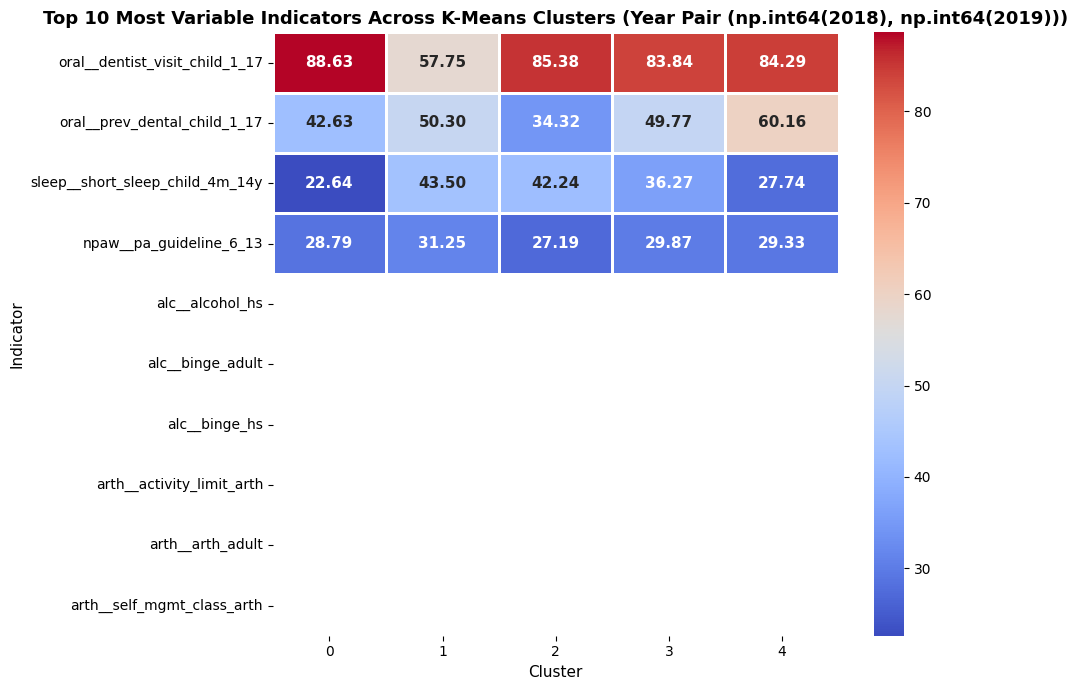


--- Cluster Profiles for Year Pair (np.int64(2019), np.int64(2019)) ---


km_cluster,0,1,2,3,4
sdoh__ins_after_preg_recent_birth,94.715,81.116,85.734,52.880,96.3
imm__pneumo_vax_65plus,75.669,72.340,67.396,72.940,33.6
cvd__hbp_adult,27.823,34.913,32.950,39.940,66.4
copd__smoking_copd_adult,29.423,45.267,34.015,47.520,12.4
cvd__med_hbp_adult,51.077,77.780,71.042,79.380,56.2
hs__fair_poor_health_adult,16.831,22.267,18.028,21.000,45.7
arth__inactive_arth,30.769,35.267,31.765,38.200,59.7
npaw__no_leisure_pa_adult,22.277,30.540,25.836,35.880,50.6
sdoh__ins_before_preg_recent_birth,88.054,81.407,86.553,65.736,95.1
dis__any_disability_adult,24.077,32.487,28.975,36.280,52.7


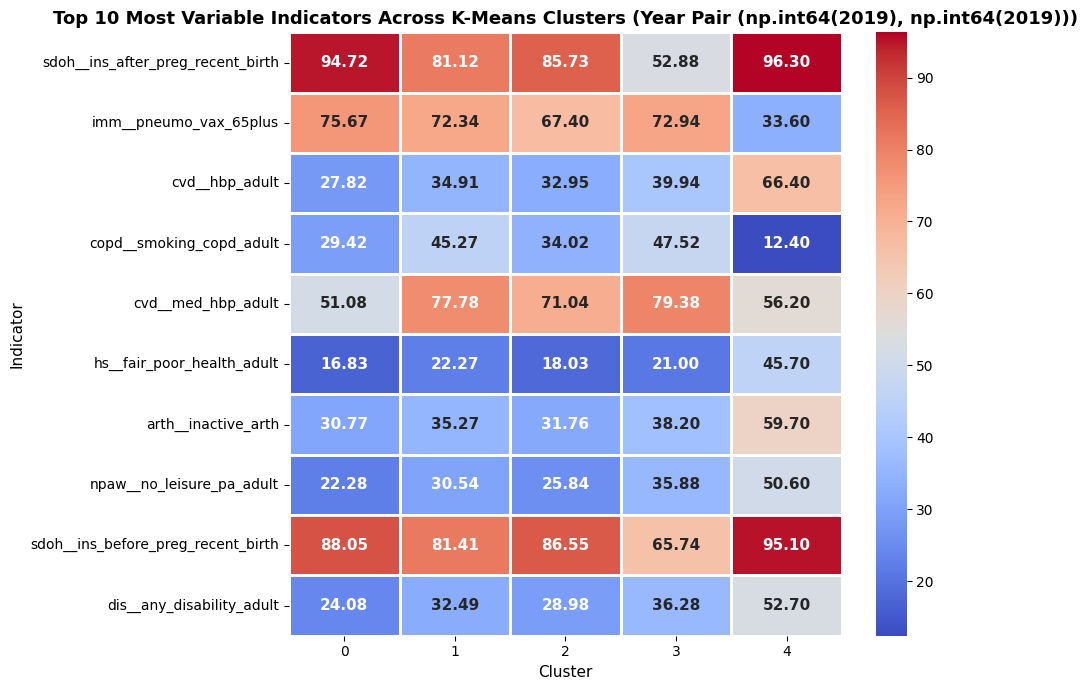


--- Cluster Profiles for Year Pair (np.int64(2019), np.int64(2020)) ---


km_cluster,0,1,2,3,4
cog__scd_discussed_hcp_45plus,41.230,50.494,30.70,55.91,44.289
cog__caregiver_dementia_adult,20.133,24.417,27.60,25.30,25.800
cog__caregiver_friend_family_adult,19.633,21.150,24.20,19.30,23.750
cog__scd_45plus,7.800,10.788,9.35,7.88,12.233
alc__alcohol_hs,NaN,NaN,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN,NaN,NaN


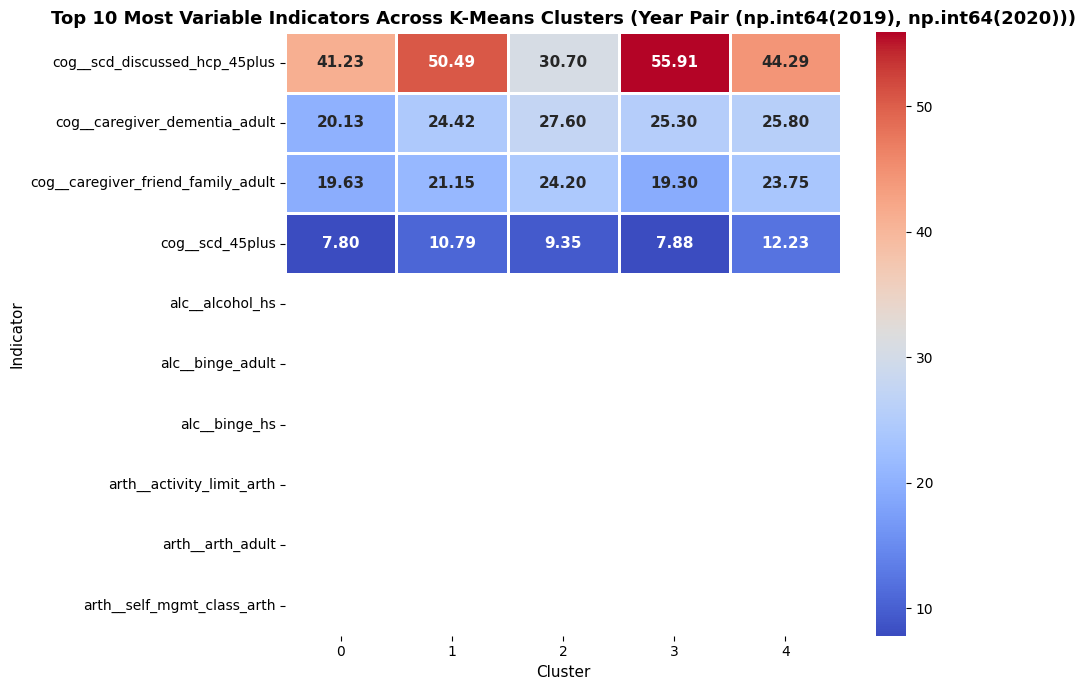


--- Cluster Profiles for Year Pair (np.int64(2020), np.int64(2020)) ---


km_cluster,0,1,2,3,4
sdoh__ins_before_preg_recent_birth,74.06,78.249,84.431,97.212,90.410
imm__flu_vax_risk_18_64,32.54,43.585,45.213,54.962,53.650
oral__no_teeth_lost_18_64,54.56,59.069,64.733,74.550,67.200
imm__flu_vax_adult,41.60,35.131,53.021,50.275,45.208
hs__chronic2plus_adult,10.46,27.577,11.668,16.450,18.825
imm__pneumo_vax_65plus,55.38,71.323,67.179,67.812,72.083
dis__any_disability_adult,38.38,29.946,26.940,20.138,28.600
oral__teeth_lost_6plus_65plus,38.12,41.385,33.687,25.350,32.192
copd__smoking_copd_adult,30.28,42.031,34.360,26.513,36.917
can__screen_cervical_w21_65,70.68,84.077,80.381,82.400,85.475


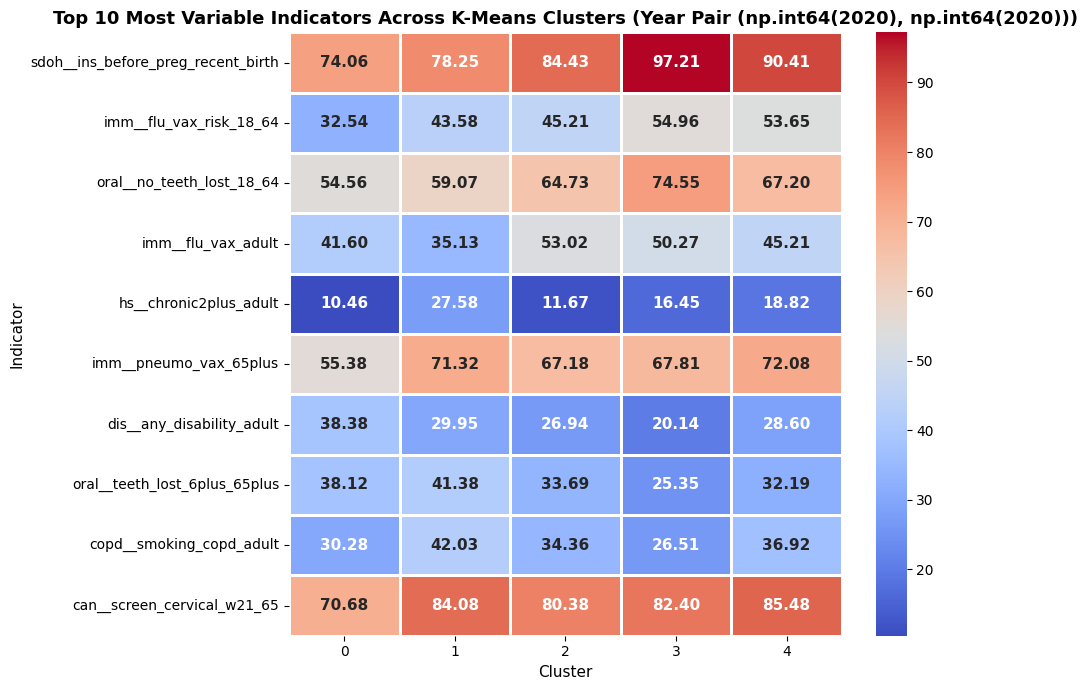


--- Cluster Profiles for Year Pair (np.int64(2020), np.int64(2021)) ---


km_cluster,0,1,2,3,4
oral__prev_dental_child_1_17,46.617,32.19,58.389,29.40,49.800
sleep__short_sleep_child_4m_14y,45.642,30.81,35.211,45.32,28.856
npaw__pa_guideline_6_13,20.967,28.19,15.700,21.46,27.662
oral__dentist_visit_child_1_17,73.458,82.81,81.878,73.28,77.700
alc__alcohol_hs,NaN,NaN,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN,NaN,NaN


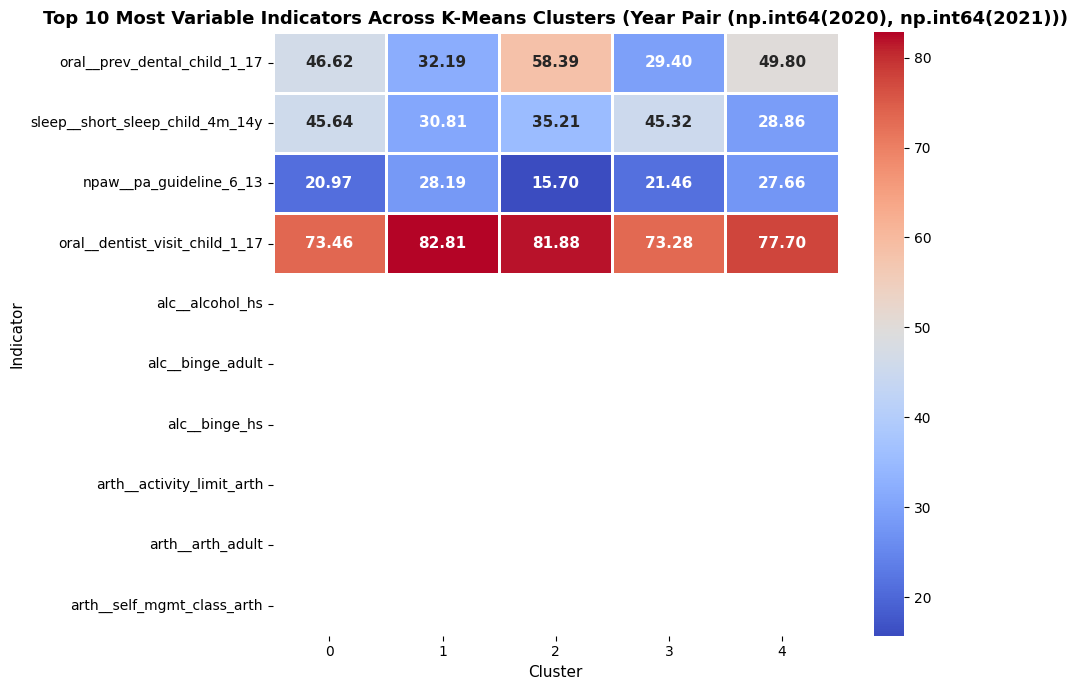


--- Cluster Profiles for Year Pair (np.int64(2021), np.int64(2021)) ---


km_cluster,0,1,2,3,4
cvd__med_hbp_adult,82.660,68.700,64.060,31.900,84.967
imm__pneumo_vax_65plus,70.053,62.613,43.360,70.650,71.833
imm__flu_vax_adult,45.391,41.620,27.820,52.925,48.044
cvd__hbp_adult,28.867,34.680,44.840,21.650,37.067
imm__flu_vax_risk_18_64,46.059,47.513,26.580,43.725,36.889
cvd__high_chol_screened_adult,31.002,39.053,51.580,46.500,37.044
sdoh__ins_after_preg_recent_birth,94.580,90.144,95.500,97.400,77.338
arth__arth_adult,24.834,24.160,30.460,13.825,35.256
arth__severe_joint_pain_arth,29.600,31.727,47.020,26.375,33.844
tob__quit_attempt_adult_smokers,51.200,49.350,46.433,64.700,49.300


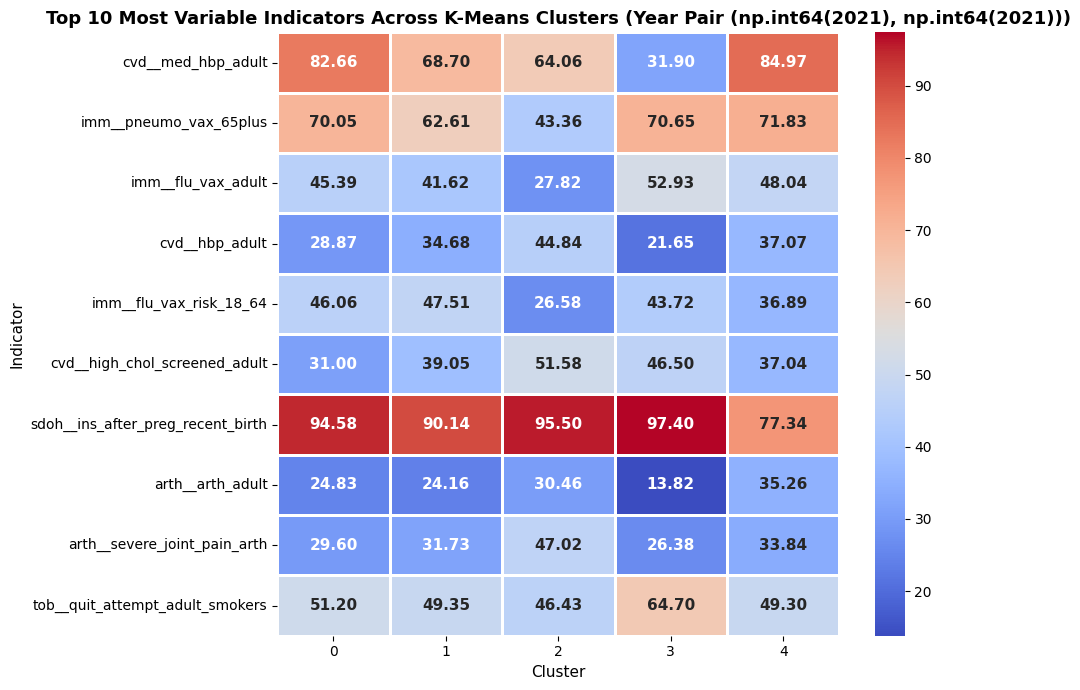


--- Cluster Profiles for Year Pair (np.int64(2021), np.int64(2022)) ---


km_cluster,0,1,2,3,4
cog__caregiver_friend_family_adult,21.227,18.352,27.088,10.362,18.78
cog__scd_discussed_hcp_45plus,38.644,45.092,44.840,39.300,50.40
cog__caregiver_dementia_adult,28.491,24.003,22.000,24.288,15.64
cog__scd_45plus,12.433,12.117,12.420,11.550,10.70
alc__alcohol_hs,NaN,NaN,NaN,NaN,NaN
alc__binge_adult,NaN,NaN,NaN,NaN,NaN
alc__binge_hs,NaN,NaN,NaN,NaN,NaN
arth__activity_limit_arth,NaN,NaN,NaN,NaN,NaN
arth__arth_adult,NaN,NaN,NaN,NaN,NaN
arth__self_mgmt_class_arth,NaN,NaN,NaN,NaN,NaN


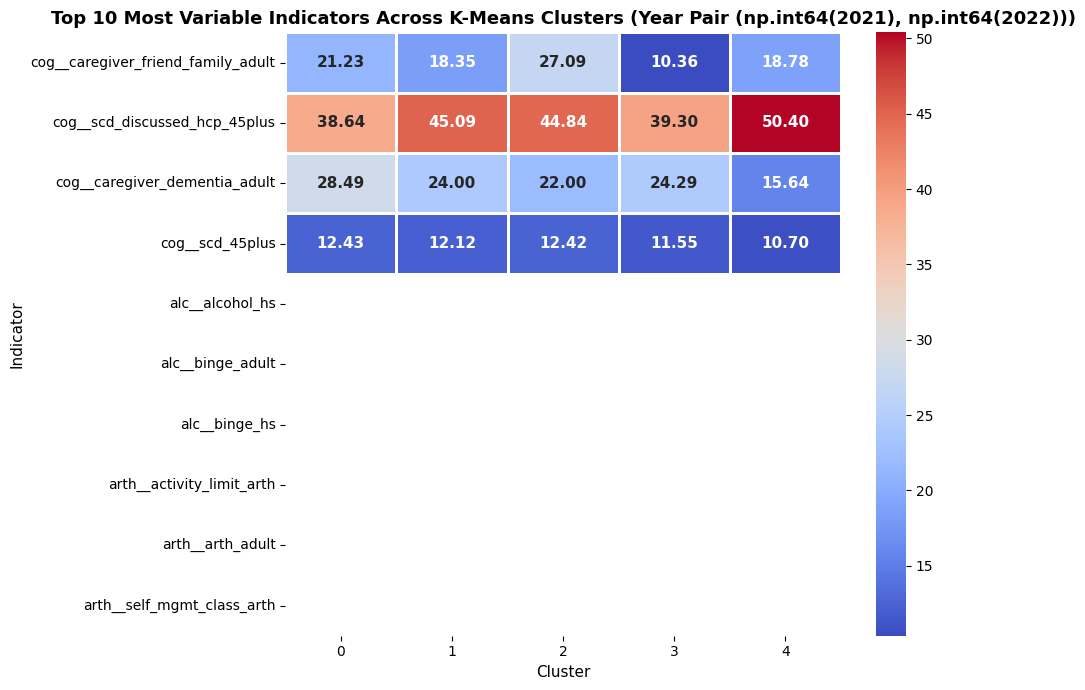


--- Cluster Profiles for Year Pair (np.int64(2022), np.int64(2022)) ---


km_cluster,0,1,2,3,4
imm__pneumo_vax_65plus,67.831,69.420,30.300,68.778,65.573
arth__arth_adult,42.569,27.233,12.200,25.500,20.787
imm__flu_vax_adult,51.038,53.680,37.633,36.900,39.700
sdoh__housing_utility_payment_issue_adult,14.709,10.775,30.700,14.540,13.333
dm__diabetes_adult,13.500,11.840,26.933,22.567,12.060
can__screen_colorectal_45_75,62.185,57.887,44.833,60.033,59.633
oral__teeth_lost_6plus_65plus,33.931,27.553,44.533,40.122,31.467
npaw__no_leisure_pa_adult,24.538,19.267,35.600,30.811,23.213
oral__no_teeth_lost_18_64,66.554,70.460,59.400,55.122,64.873
hs__chronic2plus_adult,28.623,15.333,19.767,26.633,17.753


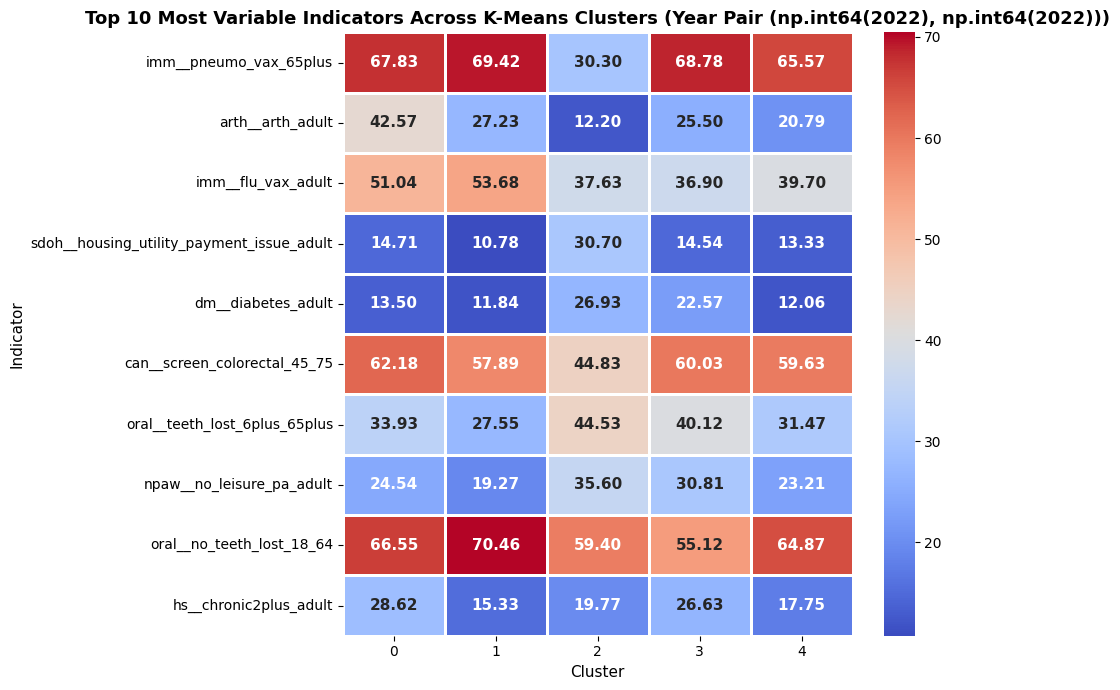

In [34]:
for year_pair, km_labels_for_pair in all_kmeans_labels.items():
    yr_start_val, yr_end_val = year_pair

    # Get the original data subset for this year_pair to extract indicator values
    current_df_subset = clean_df[(clean_df['yr_start'] == yr_start_val) & (clean_df['yr_end'] == yr_end_val)].copy()

    # Ensure indicator_cols is defined for the profiling. It was defined earlier globally.
    # If 'indicator_cols' is not global, it needs to be derived here:
    # indicator_cols = [col for col in current_df_subset.columns if '__' in col]

    profile_df_loop = current_df_subset.filter(like='__').reset_index(drop=True)
    profile_df_loop['km_cluster'] = km_labels_for_pair

    cluster_profiles_loop = profile_df_loop.groupby('km_cluster').mean().T

    # Only consider indicators that exist in this specific subset after dropping NaNs for PCA
    # The previous PCA step might have dropped some columns due to too many NaNs in a specific year_pair
    # So, we should only consider columns that are present in `profile_df_loop`
    indicator_cols_present = [col for col in profile_df_loop.columns if '__' in col]

    # Calculate std only for present indicator columns
    top_varied_loop = cluster_profiles_loop.loc[indicator_cols_present].std(axis=1).sort_values(ascending=False).head(10).index

    print(f"\n--- Cluster Profiles for Year Pair {year_pair} ---")
    display(cluster_profiles_loop.loc[top_varied_loop].round(3))

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cluster_profiles_loop.loc[top_varied_loop],
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=0.8,
        linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    plt.title(f'Top 10 Most Variable Indicators Across K-Means Clusters (Year Pair {year_pair})',
              fontsize=13, fontweight='bold')
    plt.xlabel('Cluster', fontsize=11)
    plt.ylabel('Indicator', fontsize=11)
    plt.tight_layout()
    plt.show()

### Clustering Evaluation Summary (not updated)

| Method  | Clusters | Silhouette Score | Davies-Bouldin Index |
|---------|----------|-----------------|----------------------|
| K-Means | 2        | 0.3940          | 2.4395               |
| DBSCAN  | 3        | 0.3185          | 0.7540               |

K-Means produced 2 clusters with a moderate silhouette score of 0.39, suggesting some separation but with overlap; consistent with the high-dimensional nature of the data (81 features). DBSCAN identified 3 clusters but flagged 252 of 476 observations as noise, indicating that much of the data lies in low-density regions. While DBSCAN achieved a lower Davies-Bouldin Index (0.75 vs 2.44), its high noise rate limits interpretability. K-Means is preferred here for downstream cluster profiling.

# Unsupervised Clustering (for alltime aggregated)
### Methods: K-Means and DBSCAN
Clustering is applied to the full scaled feature matrix to identify natural groupings of state-year observations based on chronic disease and behavioral profiles; independent of the high-risk label. Internal validation uses Silhouette Score and Davies-Bouldin Index. Clusters are visualized via PCA 2D projection and profiled by their top indicator patterns.

In [20]:
#PCA Setup
# Use the full dataset scaled consistently

# Collect unique year pairs
unique_year_pairs = clean_df[['yr_start', 'yr_end']].drop_duplicates().values

# Dictionaries to store PCA results for each year pair
all_X_pca_results = {}
all_pca_objects = {}
all_explained_variances = {}

print("Performing PCA for each unique (yr_start, yr_end) pair:")
for yr_start_val, yr_end_val in unique_year_pairs:
    current_X_all = clean_df[(clean_df['yr_start'] == yr_start_val) & (clean_df['yr_end'] == yr_end_val)]
    # Filter for indicator columns
    current_X_all = current_X_all.filter(like='__')
    # Drop columns that have any NaN values for this specific year group.
    # While clean_df should have been largely imputed, this ensures robustness for PCA if any NaNs remain in specific year groups.
    current_X_all = current_X_all.dropna(axis=1)

    # Ensure enough samples and features for PCA
    if not current_X_all.empty and current_X_all.shape[0] > 1 and current_X_all.shape[1] >= 2:
        pca_temp = PCA(n_components=2, random_state=42)
        X_pca_temp = pca_temp.fit_transform(current_X_all)
        explained_variance = pca_temp.explained_variance_ratio_.sum()

        all_X_pca_results[(yr_start_val, yr_end_val)] = X_pca_temp
        all_pca_objects[(yr_start_val, yr_end_val)] = pca_temp
        all_explained_variances[(yr_start_val, yr_end_val)] = explained_variance

        print(f"  Year Pair ({yr_start_val}, {yr_end_val}): Explained variance by 2 PCs: {explained_variance:.2%}")
    else:
        print(f"  Year Pair ({yr_start_val}, {yr_end_val}): Not enough valid data (rows > 1 and cols >= 2) for PCA (shape: {current_X_all.shape}). Skipping.")

Performing PCA on clean_df_alltime_processed:
  Explained variance by 2 PCs: 29.66%


### K-Means Clustering
The Elbow Method and Silhouette Score are used to select the optimal number of clusters k, then the final model is fit and evaluated.

Running K-Means for All-Time Aggregated Data:


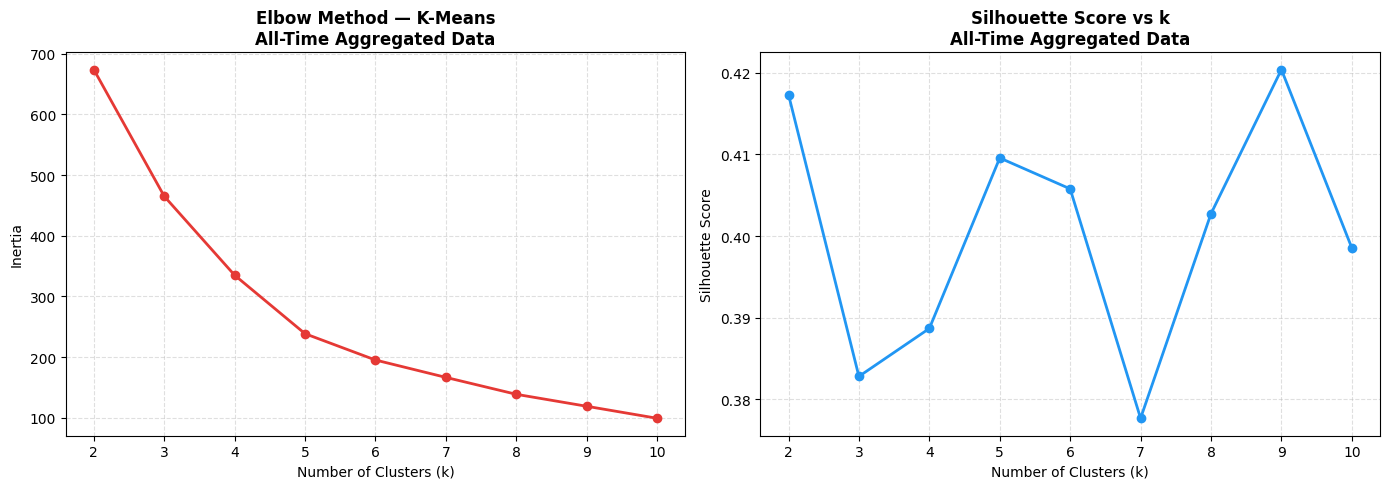

All-Time Aggregated Data | Optimal k: 9
K-Means | Silhouette: 0.4204 | Davies-Bouldin: 0.5425
------------------------------------------------------------


In [21]:
# Initialize lists to store clustering metrics for the aggregated dataset
inertias = []
sil_scores = []

print("Running K-Means for All-Time Aggregated Data:")

X_all = X_pca # Use the PCA result from the aggregated data
n_samples = X_all.shape[0]

# Need at least 3 samples for clustering with k >= 2
if n_samples < 3:
    print(f"Not enough samples for clustering (n={n_samples}). Skipping.")
else:
    # Adaptive k range
    max_k = min(10, n_samples - 1)
    if max_k < 2:
        print(f"max_k < 2. Skipping K-Means.")
    else:
        k_range = range(2, max_k + 1)

        # Compute clustering metrics across k
        for k in k_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(X_all)

            inertias.append(km.inertia_)

            # silhouette requires at least 2 clusters and fewer clusters than samples
            if len(np.unique(labels)) > 1 and len(np.unique(labels)) < n_samples:
                sil_scores.append(silhouette_score(X_all, labels))
            else:
                sil_scores.append(np.nan)

        # Plot for the aggregated data
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(k_range, inertias, marker='o', color='#E53935', linewidth=2)
        axes[0].set_title('Elbow Method — K-Means\nAll-Time Aggregated Data', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].grid(True, linestyle='--', alpha=0.4)

        axes[1].plot(k_range, sil_scores, marker='o', color='#2196F3', linewidth=2)
        axes[1].set_title('Silhouette Score vs k\nAll-Time Aggregated Data', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Silhouette Score')
        axes[1].grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

        # Choose best k based on silhouette
        valid_sil = [s for s in sil_scores if not np.isnan(s)]
        if len(valid_sil) == 0:
            print(f"No valid silhouette scores. Skipping final K-Means.")
        else:
            best_idx = int(np.nanargmax(sil_scores))
            best_k = list(k_range)[best_idx]

            # Final KMeans for this aggregated data
            km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
            km_labels = km_final.fit_predict(X_all)

            km_sil = silhouette_score(X_all, km_labels)
            km_db = davies_bouldin_score(X_all, km_labels)

            all_kmeans_labels = km_labels # Store as a single variable now
            all_kmeans_models = km_final # Store as a single variable now
            all_best_k = best_k # Store as a single variable now
            all_kmeans_metrics = { # Store as a single variable now
                'best_k': best_k,
                'silhouette': km_sil,
                'davies_bouldin': km_db
            }

            print(f"All-Time Aggregated Data | Optimal k: {best_k}")
            print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
            print("-" * 60)

In [27]:
# Manually set the number of clusters (K)
# Please provide your desired K value when prompted, or set it directly here.
manual_k = 5 # Placeholder. You will be prompted to enter this value.

# Fallback if running non-interactively or if no input is given
if manual_k is None:
    try:
        manual_k = int(input("Enter your desired K value for K-Means clustering (e.g., 3, 5, 7): "))
    except ValueError:
        print("Invalid input. Using default K=5.")
        manual_k = 5


print(f"Running K-Means with a manual K value of {manual_k} for All-Time Aggregated Data:")

X_all = X_pca # Use the PCA result from the aggregated data
n_samples = X_all.shape[0]

if n_samples < manual_k:
    print(f"Not enough samples ({n_samples}) for K-Means with K={manual_k}. Skipping.")
elif manual_k < 2:
    print(f"K must be at least 2 for K-Means. Skipping.")
else:
    # Perform K-Means clustering with the manual K value
    km_final = KMeans(n_clusters=manual_k, random_state=42, n_init=10)
    km_labels = km_final.fit_predict(X_all)

    # Evaluate the clustering
    km_sil = silhouette_score(X_all, km_labels)
    km_db = davies_bouldin_score(X_all, km_labels)

    # Store results using the requested variable names
    all_kmeans_labels = km_labels
    all_best_k = manual_k # Storing the manual K as 'all_best_k' as requested
    all_kmeans_models = km_final
    all_kmeans_metrics = {
        'best_k': manual_k,
        'silhouette': km_sil,
        'davies_bouldin': km_db
    }

    print(f"All-Time Aggregated Data | Manual K: {manual_k}")
    print(f"K-Means | Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print("-" * 60)


Running K-Means with a manual K value of 5 for All-Time Aggregated Data:
All-Time Aggregated Data | Manual K: 5
K-Means | Silhouette: 0.4096 | Davies-Bouldin: 0.7510
------------------------------------------------------------


### DBSCAN Clustering
DBSCAN identifies clusters of arbitrary shape and marks low-density observations as noise (label = −1). Epsilon and min_samples are tuned via a parameter sweep maximizing silhouette score.

Running DBSCAN for All-Time Aggregated Data:
All-Time Aggregated Data | Best eps=2.0, min_samples=3
DBSCAN clusters: 2 | Noise points: 7
DBSCAN | Silhouette: 0.4856 | Davies-Bouldin: 0.5118
------------------------------------------------------------


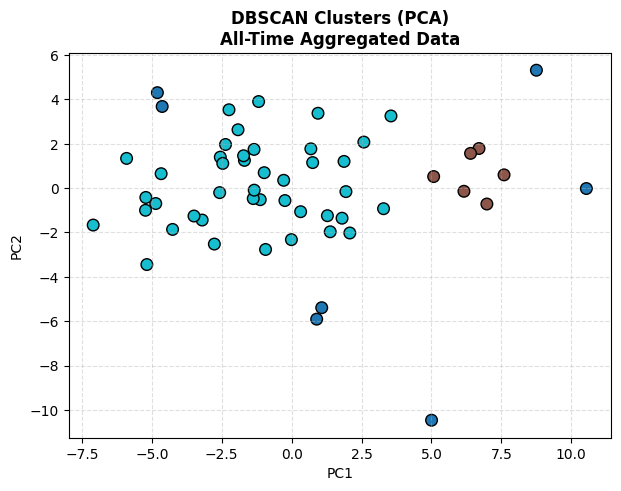

In [22]:
# Store results as single variables now, not dictionaries
# all_dbscan_params = {}
# all_dbscan_labels = {}
# all_dbscan_metrics = {}

print("Running DBSCAN for All-Time Aggregated Data:")

X_all = X_pca # Use the PCA result from the aggregated data
n_samples = X_all.shape[0]

if n_samples < 5:
    print(f"Not enough samples for DBSCAN (n={n_samples}). Skipping.")
else:
    best_sil_db = -1
    best_eps = None
    best_min_samp = None
    best_labels = None

    # Parameter grid (can be tuned further)
    eps_values = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5]
    min_samples_values = [3, 5, 7, 10]

    for eps, min_s in product(eps_values, min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_all)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Need at least 2 clusters for silhouette
        if n_clusters >= 2:
            try:
                sil = silhouette_score(X_all, labels)
                if sil > best_sil_db:
                    best_sil_db = sil
                    best_eps = eps
                    best_min_samp = min_s
                    best_labels = labels
            except:
                continue

    # If no valid clustering found
    if best_labels is None:
        print(f"No valid DBSCAN clustering found.")
    else:
        # Final model with best params
        db_final = DBSCAN(eps=best_eps, min_samples=best_min_samp)
        db_labels = db_final.fit_predict(X_all)

        n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise_db = list(db_labels).count(-1)

        print(f"All-Time Aggregated Data | Best eps={best_eps}, min_samples={best_min_samp}")
        print(f"DBSCAN clusters: {n_clusters_db} | Noise points: {n_noise_db}")

        # Evaluate only non-noise points
        non_noise = db_labels != -1

        if non_noise.sum() > 0 and len(set(db_labels[non_noise])) >= 2:
            db_sil = silhouette_score(X_all[non_noise], db_labels[non_noise])
            db_db = davies_bouldin_score(X_all[non_noise], db_labels[non_noise])

            print(f"DBSCAN | Silhouette: {db_sil:.4f} | Davies-Bouldin: {db_db:.4f}")

            all_dbscan_metrics = {
                'eps': best_eps,
                'min_samples': best_min_samp,
                'n_clusters': n_clusters_db,
                'noise_points': n_noise_db,
                'silhouette': db_sil,
                'davies_bouldin': db_db
            }
        else:
            print("DBSCAN: insufficient clusters for evaluation.")
            all_dbscan_metrics = {
                'eps': best_eps,
                'min_samples': best_min_samp,
                'n_clusters': n_clusters_db,
                'noise_points': n_noise_db,
                'silhouette': None,
                'davies_bouldin': None
            }

        all_dbscan_labels = db_labels # Store as a single variable now
        all_dbscan_params = (best_eps, best_min_samp) # Store as a single variable now

        print("-" * 60)

        # ┅ Optional: Visualization
        plt.figure(figsize=(7, 5))
        plt.scatter(X_all[:, 0], X_all[:, 1], c=db_labels, cmap='tab10', s=70, edgecolor='k')
        plt.title(f'DBSCAN Clusters (PCA)\nAll-Time Aggregated Data',
                  fontsize=12, fontweight='bold')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.show()

### Cluster Visualization & Profiling
Observations are projected onto 2 principal components and colored by cluster. K-Means clusters are then profiled by the top indicators that vary most across groups.

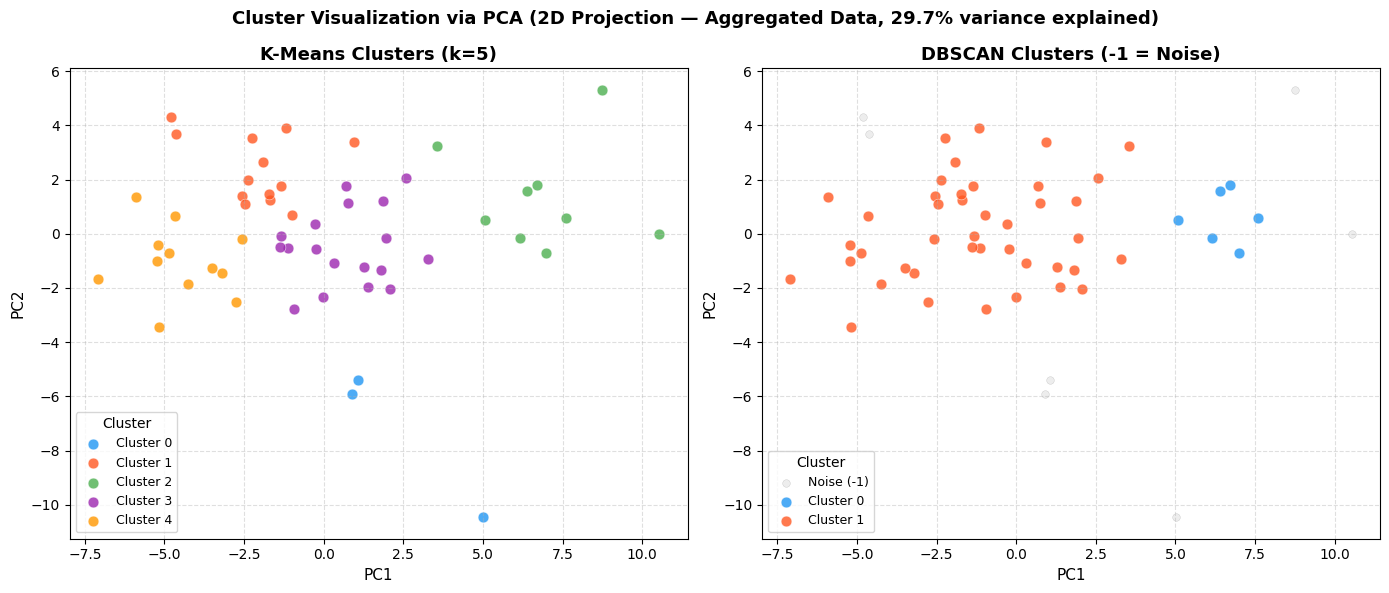

In [26]:
# Access the global variables for the aggregated data
# X_pca, km_labels, db_labels, all_best_k, explained_variance_pca are now single variables
# from the previous cells operating on clean_df_alltime_processed

km_labels = all_kmeans_labels
db_labels = all_dbscan_labels
best_k = all_best_k
explained_var = explained_variance_pca

# For aggregated data, we don't have 'yr_start', 'yr_end', or 'risk_label' in the same context
# as the time-series clean_df. So, ground truth plotting is removed.
plot_ground_truth = False

n_panels = 2 # Only K-Means and DBSCAN plots
fig, axes = plt.subplots(1, n_panels, figsize=(14, 6))

# --- Panel 1: K-Means clusters ---
km_unique = np.unique(km_labels)
km_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
              '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

for i, label in enumerate(km_unique):
    mask = km_labels == label
    color = km_palette[i % len(km_palette)]
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=f'Cluster {label}',
        alpha=0.8, s=60, edgecolors='white', linewidths=0.4
    )

axes[0].set_title(f'K-Means Clusters (k={best_k})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].legend(title='Cluster', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Panel 2: DBSCAN clusters ---
db_unique = np.unique(db_labels)
db_palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
              '#FF9800', '#00BCD4', '#E91E63', '#8BC34A']

for label in db_unique:
    mask = db_labels == label
    if label == -1:
        axes[1].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c='lightgray', label='Noise (-1)',
            alpha=0.4, s=30, edgecolors='gray', linewidths=0.3
        )
    else:
        color = db_palette[int(label) % len(db_palette)]
        axes[1].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=color, label=f'Cluster {label}',
            alpha=0.8, s=60, edgecolors='white', linewidths=0.4
        )

axes[1].set_title('DBSCAN Clusters (-1 = Noise)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].legend(title='Cluster', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    f'Cluster Visualization via PCA (2D Projection — Aggregated Data, {explained_var:.1%} variance explained)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

km_cluster,0,1,2,3,4
imm__pneumo_vax_65plus,34.713,70.102,70.267,68.940,68.628
imm__flu_vax_risk_18_64,29.958,47.367,39.583,43.092,49.388
arth__severe_joint_pain_arth,43.550,26.142,40.656,35.733,29.601
cvd__high_chol_screened_adult,48.300,29.350,36.906,36.871,32.559
oral__teeth_lost_6plus_65plus,43.563,31.054,42.933,33.314,27.942
copd__smoking_copd_adult,28.539,36.185,45.896,35.980,29.000
arth__arth_adult,14.694,30.387,32.581,26.569,24.038
arth__inactive_arth,44.433,29.392,37.700,32.980,27.908
npaw__veg_lt1_daily_adult,35.400,20.438,21.900,20.789,21.789
npaw__pa_guideline_adult,41.208,55.062,45.100,51.722,55.247


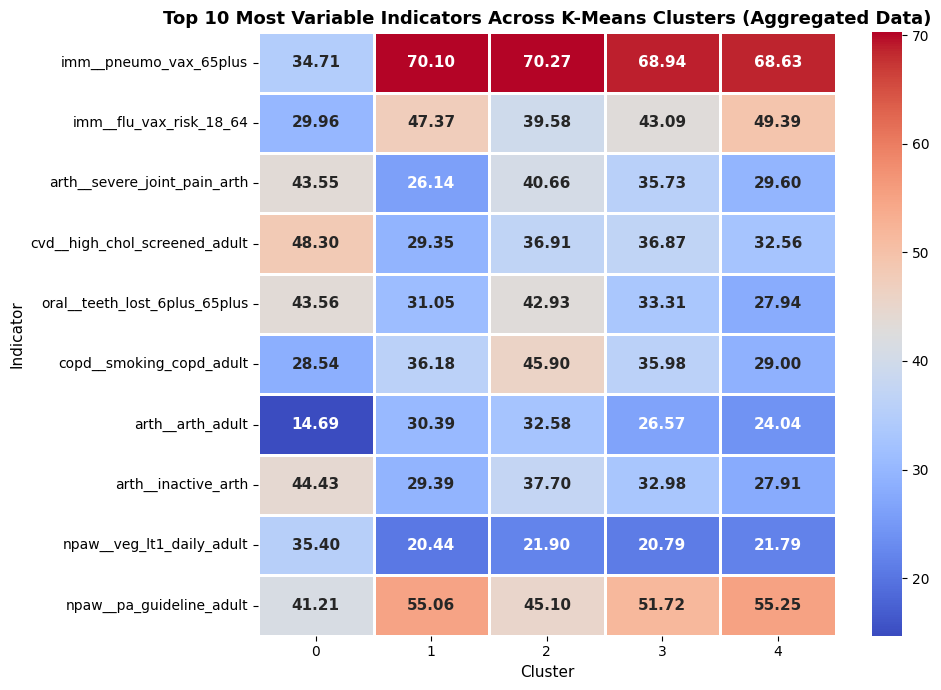

In [28]:
profile_df = X_all_processed.reset_index(drop=True).copy()
profile_df['km_cluster'] = all_kmeans_labels

cluster_profiles = profile_df.groupby('km_cluster').mean().T

top_varied = cluster_profiles.std(axis=1).sort_values(ascending=False).head(10).index
display(cluster_profiles.loc[top_varied].round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(
    cluster_profiles.loc[top_varied],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Top 10 Most Variable Indicators Across K-Means Clusters (Aggregated Data)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Indicator', fontsize=11)
plt.tight_layout()
plt.show()